In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load the data
data_path = "C:/Users/sneha/major project/Disease Dataset/synthetic_kidney_disease_5000.csv"
df = pd.read_csv(data_path)

In [5]:
df.shape

(5000, 26)

In [7]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              5000 non-null   int64  
 1   age             4877 non-null   float64
 2   bp              4834 non-null   float64
 3   sg              4423 non-null   float64
 4   al              4443 non-null   float64
 5   su              4401 non-null   float64
 6   rbc             3159 non-null   object 
 7   pc              4186 non-null   object 
 8   pcc             4956 non-null   object 
 9   ba              4956 non-null   object 
 10  bgr             4430 non-null   float64
 11  bu              4758 non-null   float64
 12  sc              4779 non-null   float64
 13  sod             3913 non-null   float64
 14  pot             3901 non-null   float64
 15  hemo            4333 non-null   float64
 16  pcv             4103 non-null   object 
 17  wc              3691 non-null   o

In [11]:
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,5000.000000,4877.000000,4834.000000,4423.000000,4443.000000,4401.000000,4430.000000,4758.000000,4779.000000,3913.000000,3901.000000,4333.000000
mean,198.765800,51.759073,76.315681,1.017421,1.018006,0.444672,148.620767,57.462589,3.059761,137.438283,4.632274,12.512116
std,115.500546,17.230926,13.564738,0.005690,1.351418,1.101526,78.315292,50.965319,5.855446,10.246182,3.245301,2.884843
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,101.000000,42.000000,70.000000,1.010000,0.000000,0.000000,100.000000,27.000000,0.900000,135.000000,3.800000,10.400000
50%,196.000000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,41.000000,1.200000,138.000000,4.400000,12.600000
75%,300.000000,65.000000,80.000000,1.020000,2.000000,0.000000,165.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


**Performing Exploitory Data Analysis ( EDA )**

In [13]:
print(df.columns)


Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')


In [15]:
df = df.drop('id', axis=1)

In [27]:
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [29]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4877.0,51.759073,17.230926,2.000,42.00,55.00,65.00,90.000
blood_pressure,4834.0,76.315681,13.564738,50.000,70.00,80.00,80.00,180.000
specific_gravity,4423.0,1.017421,0.005690,1.005,1.01,1.02,1.02,1.025
albumin,4443.0,1.018006,1.351418,0.000,0.00,0.00,2.00,5.000
sugar,4401.0,0.444672,1.101526,0.000,0.00,0.00,0.00,5.000
blood_glucose_random,4430.0,148.620767,78.315292,22.000,100.00,121.00,165.00,490.000
blood_urea,4758.0,57.462589,50.965319,1.500,27.00,41.00,66.00,391.000
serum_creatinine,4779.0,3.059761,5.855446,0.400,0.90,1.20,2.80,76.000
sodium,3913.0,137.438283,10.246182,4.500,135.00,138.00,142.00,163.000
potassium,3901.0,4.632274,3.245301,2.500,3.80,4.40,4.90,47.000


In [33]:
def convert_dtype(df,feature):
    df[feature]=pd.to_numeric(df[feature],errors='coerce')    #whereever we have Nan values , this errors parameter will hanfle that 

In [35]:
features=['packed_cell_volume','white_blood_cell_count','red_blood_cell_count']
for i in features:
    convert_dtype(df,i)

In [37]:
df.dtypes

age                        float64
blood_pressure             float64
specific_gravity           float64
albumin                    float64
sugar                      float64
red_blood_cells             object
pus_cell                    object
pus_cell_clumps             object
bacteria                    object
blood_glucose_random       float64
blood_urea                 float64
serum_creatinine           float64
sodium                     float64
potassium                  float64
haemoglobin                float64
packed_cell_volume         float64
white_blood_cell_count     float64
red_blood_cell_count       float64
hypertension                object
diabetes_mellitus           object
coronary_artery_disease     object
appetite                    object
peda_edema                  object
aanemia                     object
class                       object
dtype: object

**Performing Data cleaning**

In [39]:
def extract_cat_num(df):
    cat_col=[col for col in df.columns if df[col].dtype=='O']
    num_col=[col for col in df.columns if df[col].dtype!='O']
    return cat_col,num_col

In [41]:
cat_col,num_col=extract_cat_num(df)

In [43]:
cat_col

['red_blood_cells',
 'pus_cell',
 'pus_cell_clumps',
 'bacteria',
 'hypertension',
 'diabetes_mellitus',
 'coronary_artery_disease',
 'appetite',
 'peda_edema',
 'aanemia',
 'class']

In [45]:
num_col

['age',
 'blood_pressure',
 'specific_gravity',
 'albumin',
 'sugar',
 'blood_glucose_random',
 'blood_urea',
 'serum_creatinine',
 'sodium',
 'potassium',
 'haemoglobin',
 'packed_cell_volume',
 'white_blood_cell_count',
 'red_blood_cell_count']

In [47]:
# dirtiness in categorical data
for col in cat_col:
    print('{} has {} values'.format(col,df[col].unique()))
    print("\n")

red_blood_cells has [nan 'normal' 'abnormal'] values


pus_cell has ['normal' 'abnormal' nan] values


pus_cell_clumps has ['notpresent' 'present' nan] values


bacteria has ['notpresent' 'present' nan] values


hypertension has ['yes' 'no' nan] values


diabetes_mellitus has ['yes' 'no' ' yes' '\tno' '\tyes' nan] values


coronary_artery_disease has ['no' 'yes' '\tno' nan] values


appetite has ['good' 'poor' nan] values


peda_edema has ['no' 'yes' nan] values


aanemia has ['no' 'yes' nan] values


class has ['ckd' 'ckd\t' 'notckd'] values




In [51]:
df['diabetes_mellitus'].replace({'\tno': 'no', '\tyes': 'yes'}, inplace=True)
df['coronary_artery_disease'].replace({'\tno': 'no'}, inplace=True)
df['class'].replace({'ckd\t': 'ckd'}, inplace=True)

In [53]:
# no dirtiness
for col in cat_col:
    print('{} has {} values'.format(col,df[col].unique()))
    print("\n")

red_blood_cells has [nan 'normal' 'abnormal'] values


pus_cell has ['normal' 'abnormal' nan] values


pus_cell_clumps has ['notpresent' 'present' nan] values


bacteria has ['notpresent' 'present' nan] values


hypertension has ['yes' 'no' nan] values


diabetes_mellitus has ['yes' 'no' ' yes' nan] values


coronary_artery_disease has ['no' 'yes' nan] values


appetite has ['good' 'poor' nan] values


peda_edema has ['no' 'yes' nan] values


aanemia has ['no' 'yes' nan] values


class has ['ckd' 'notckd'] values




**Analysing distribution of each and every column**

In [55]:
len(num_col)

14

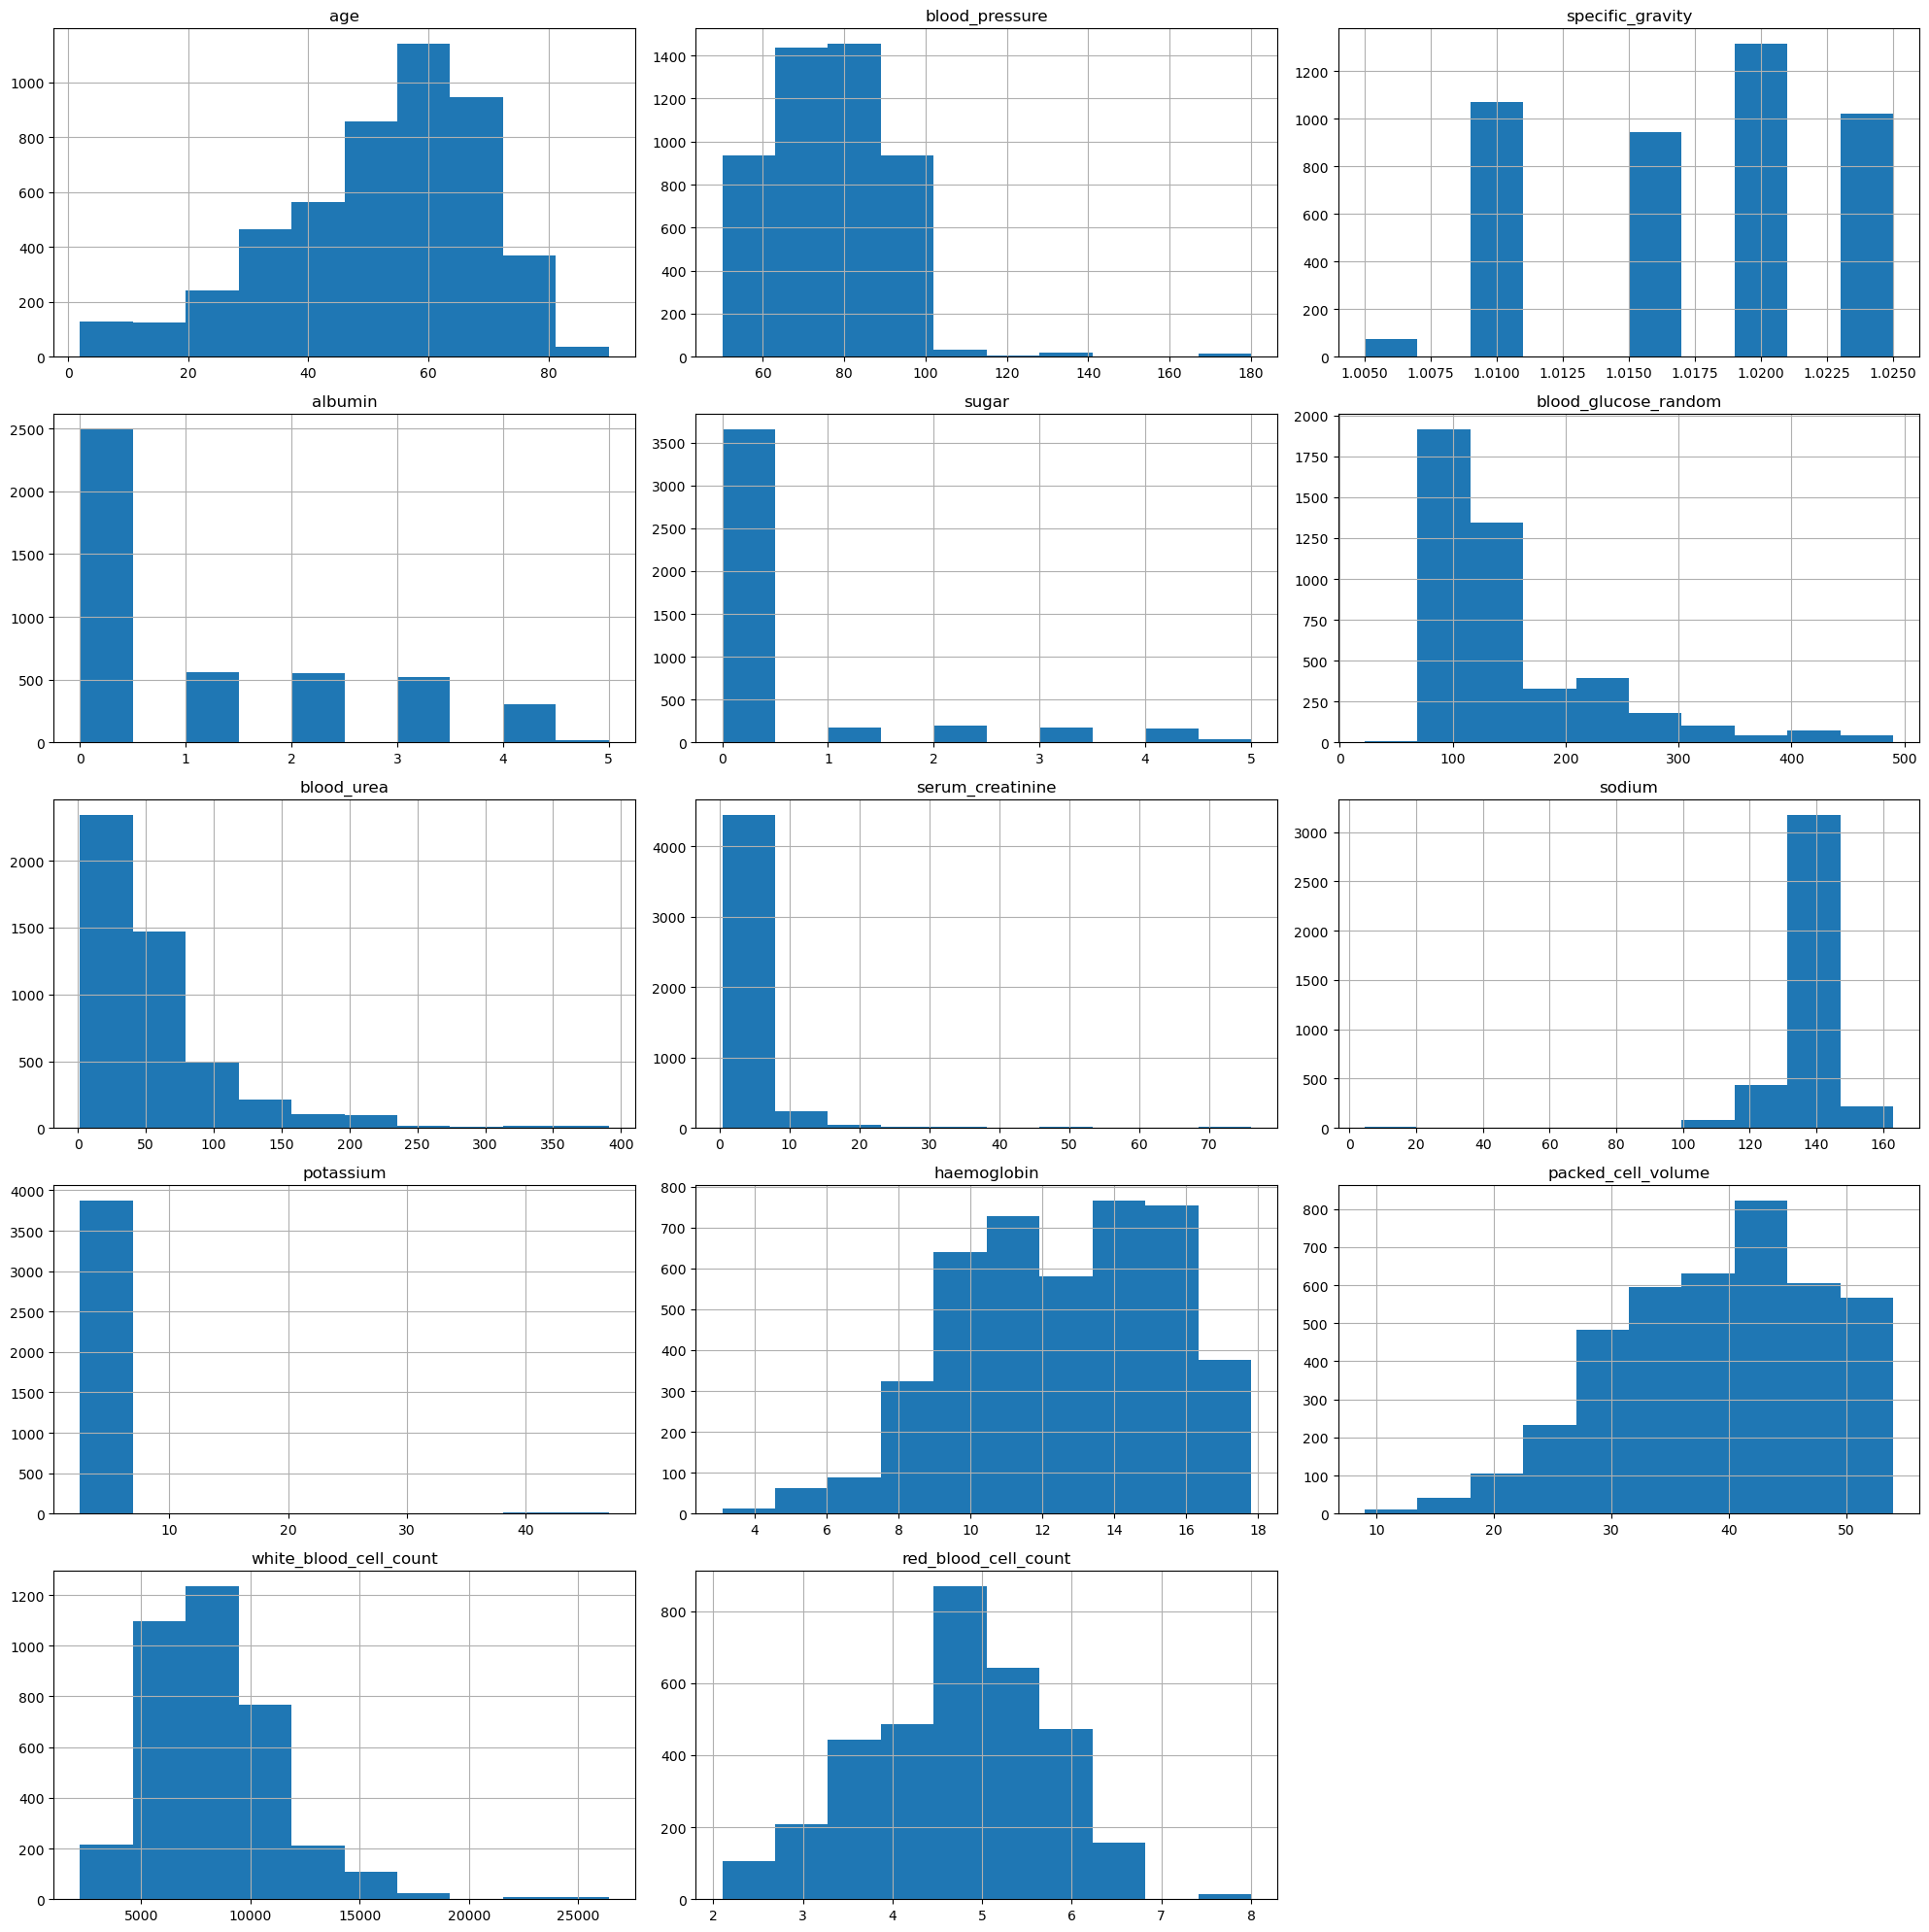

In [57]:
plt.figure(figsize=(20,20))  # Adjusted the figsize for clarity

for i, feature in enumerate(num_col):
    plt.subplot(5, 3, i + 1)  # 5 rows and 3 columns
    df[feature].hist()
    plt.title(feature)

plt.tight_layout()  # Adjust the spacing to prevent overlap
plt.show()


**Check Label distribution of categorical Data**

In [59]:
len(cat_col)

11

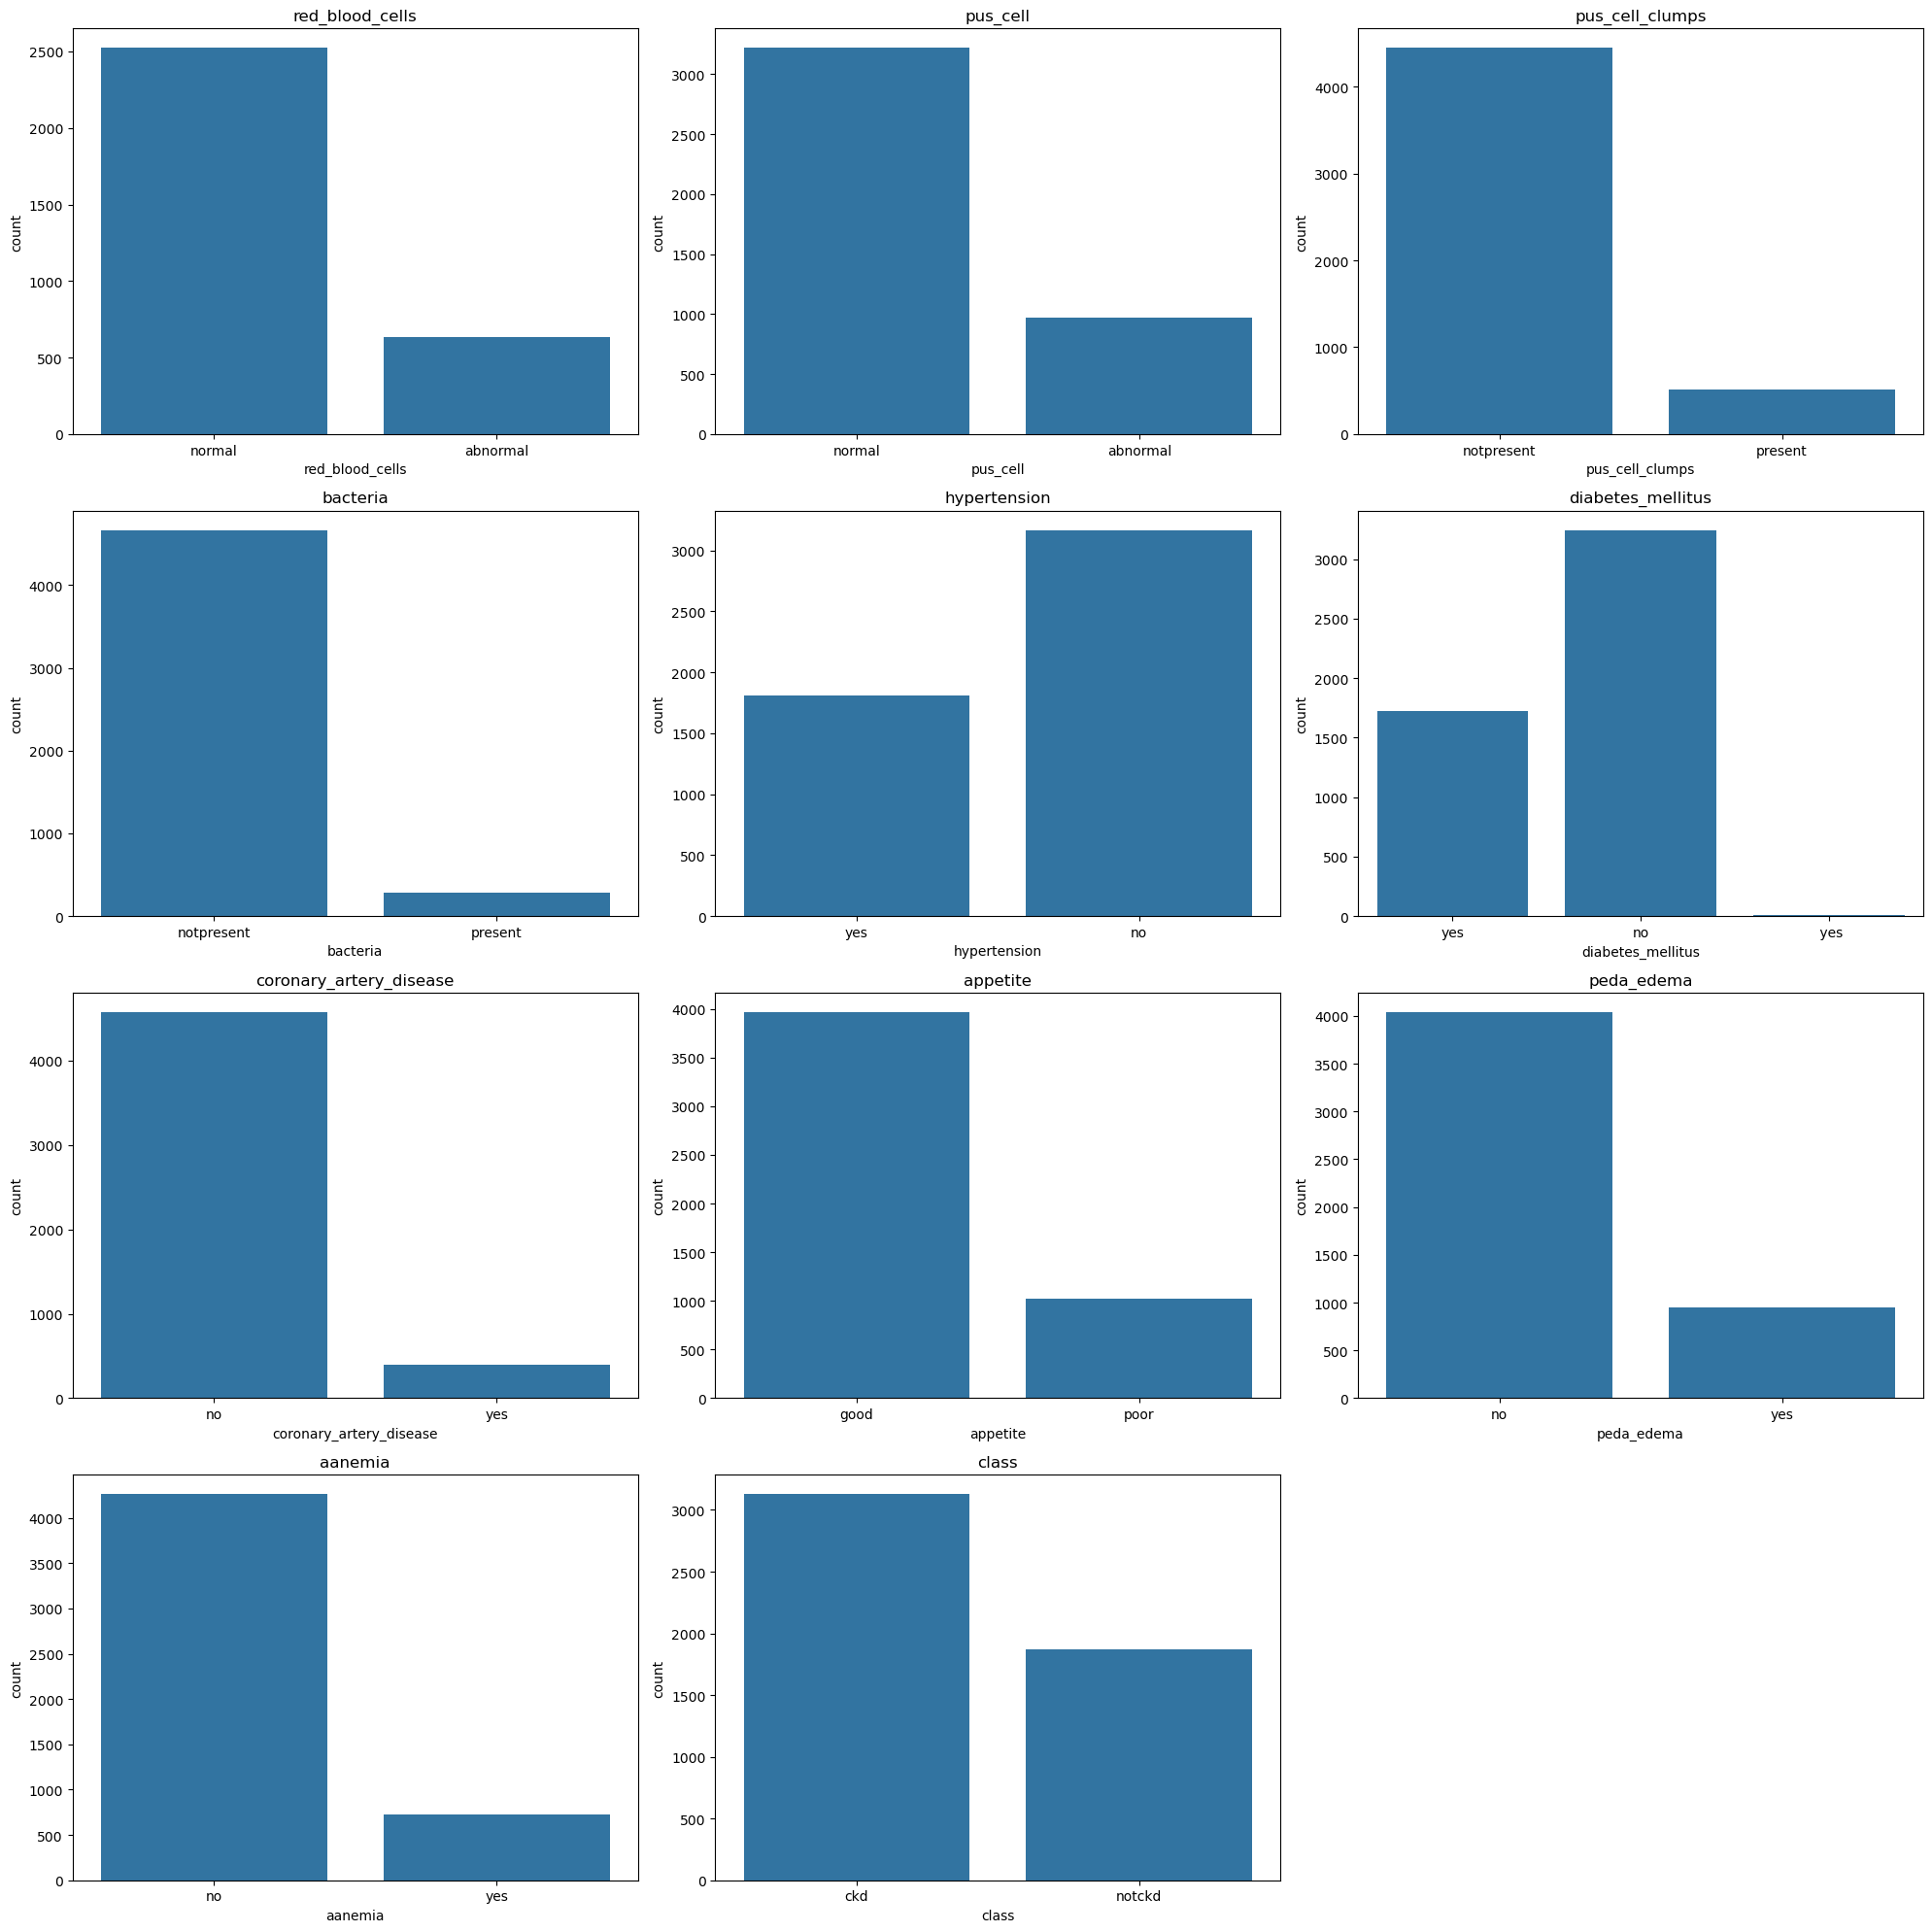

In [61]:
plt.figure(figsize=(20,20))

for i, feature in enumerate(cat_col):
    plt.subplot(4, 3, i + 1)  # 4 rows and 3 columns
    sns.countplot(x=df[feature])
    plt.title(feature)

plt.tight_layout()  # Adjust the spacing to prevent overlap
plt.show()


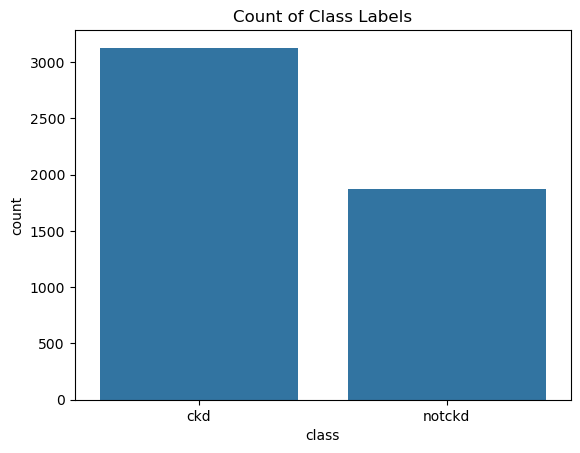

In [63]:
sns.countplot(x=df['class'])
plt.title('Count of Class Labels')
plt.show()


**Replacing Categorical values with numbers:**

In [65]:
#1. rbc
df['red_blood_cells'].value_counts()

red_blood_cells
normal      2524
abnormal     635
Name: count, dtype: int64

In [69]:
df['red_blood_cells'] = df['red_blood_cells'].replace({'normal': 0, 'abnormal': 1})

In [71]:
#pc
df['pus_cell'].value_counts()

pus_cell
normal      3219
abnormal     967
Name: count, dtype: int64

In [75]:
df['pus_cell'] = df['pus_cell'].replace({'normal': 0, 'abnormal': 1})

In [77]:
# pcc
df['pus_cell_clumps'].value_counts()

pus_cell_clumps
notpresent    4447
present        509
Name: count, dtype: int64

In [81]:
df['pus_cell_clumps'] = df['pus_cell_clumps'].replace({'notpresent': 0, 'present': 1})

In [83]:
#ba
df['bacteria'].value_counts()

bacteria
notpresent    4669
present        287
Name: count, dtype: int64

In [87]:
df['bacteria'] = df['bacteria'].replace({'notpresent': 0, 'present': 1})

In [89]:
#htn
df['hypertension'].value_counts()

hypertension
no     3168
yes    1810
Name: count, dtype: int64

In [93]:
df['hypertension'] = df['hypertension'].replace({'yes': 1, 'no': 0})

In [95]:
#dm
df['diabetes_mellitus'].value_counts()

diabetes_mellitus
no      3247
yes     1723
 yes       8
Name: count, dtype: int64

In [97]:
df['diabetes_mellitus'] = df['diabetes_mellitus'].replace(to_replace = {'\tyes':'yes', ' yes':'yes', '\tno':'no'})

In [101]:
df['diabetes_mellitus'] = df['diabetes_mellitus'].replace({'yes': 1, 'no': 0})

In [103]:
#cad
df['coronary_artery_disease'].value_counts()

coronary_artery_disease
no     4576
yes     402
Name: count, dtype: int64

In [107]:
df['coronary_artery_disease'] = df['coronary_artery_disease'].replace({'yes': 1, 'no': 0})

In [109]:
#appet
df['appetite'].unique()

array(['good', 'poor', nan], dtype=object)

In [113]:
import numpy as np  # Ensure numpy is imported

df['appetite'] = df['appetite'].replace({'good': 1, 'poor': 0, 'no': np.nan})

In [115]:
#pe
df['peda_edema'].value_counts()

peda_edema
no     4042
yes     946
Name: count, dtype: int64

In [119]:
df['peda_edema'] = df['peda_edema'].replace({'yes' : 1, 'no' : 0})

In [121]:
#ane
df['aanemia'].value_counts()

aanemia
no     4264
yes     724
Name: count, dtype: int64

In [125]:
df['aanemia'] = df['aanemia'].replace({'yes' : 1, 'no' : 0})

In [127]:
#classification
df['class'].value_counts()

class
ckd       3129
notckd    1871
Name: count, dtype: int64

In [129]:
df["class"] = [1 if i == "ckd" else 0 for i in df["class"]]

In [131]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,0.0,0.0,0.0,121.0,...,44.0,7800.0,5.2,1.0,1.0,0.0,1.0,0.0,0.0,1
1,7.0,50.0,1.020,4.0,0.0,NaN,0.0,0.0,0.0,NaN,...,38.0,6000.0,NaN,0.0,0.0,0.0,1.0,0.0,0.0,1
2,62.0,80.0,1.010,2.0,3.0,0.0,0.0,0.0,0.0,423.0,...,31.0,7500.0,NaN,0.0,1.0,0.0,0.0,0.0,1.0,1
3,48.0,70.0,1.005,4.0,0.0,0.0,1.0,1.0,0.0,117.0,...,32.0,6700.0,3.9,1.0,0.0,0.0,0.0,1.0,1.0,1
4,51.0,80.0,1.010,2.0,0.0,0.0,0.0,0.0,0.0,106.0,...,35.0,7300.0,4.6,0.0,0.0,0.0,1.0,0.0,0.0,1


**Correlation between features**

In [133]:
df.corr()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
age,1.000000,0.154512,-0.186210,0.109031,0.193592,0.125501,0.144642,0.154437,0.047355,0.228303,...,-0.242179,0.106105,-0.267624,0.396748,0.358738,0.229339,-0.170332,0.098336,0.057326,0.236730
blood_pressure,0.154512,1.000000,-0.212563,0.154771,0.249681,0.308871,0.205786,0.047574,0.121339,0.179363,...,-0.327768,0.033818,-0.270322,0.265592,0.237561,0.070500,-0.159254,0.043658,0.213071,0.282518
specific_gravity,-0.186210,-0.212563,1.000000,-0.463177,-0.310344,-0.394545,-0.373113,-0.298665,-0.218499,-0.399819,...,0.621767,-0.280333,0.590055,-0.385069,-0.429269,-0.158659,0.272148,-0.298885,-0.243062,-0.739105
albumin,0.109031,0.154771,-0.463177,1.000000,0.249458,0.464388,0.557724,0.388700,0.388092,0.377097,...,-0.604498,0.226374,-0.561014,0.524528,0.392331,0.258282,-0.350315,0.470083,0.295512,0.626671
sugar,0.193592,0.249681,-0.310344,0.249458,1.000000,0.186065,0.202586,0.122989,0.119702,0.696055,...,-0.240484,0.190129,-0.232586,0.290944,0.504741,0.235216,-0.066170,0.153417,0.064778,0.338552
red_blood_cells,0.125501,0.308871,-0.394545,0.464388,0.186065,1.000000,0.423258,0.099938,0.191875,0.336380,...,-0.457450,0.028832,-0.398671,0.308162,0.356597,0.210647,-0.276463,0.304107,0.175370,0.564757
pus_cell,0.144642,0.205786,-0.373113,0.557724,0.202586,0.423258,1.000000,0.490040,0.348097,0.349555,...,-0.535544,0.127869,-0.539716,0.390738,0.293157,0.223146,-0.303021,0.428259,0.320353,0.468210
pus_cell_clumps,0.154437,0.047574,-0.298665,0.388700,0.122989,0.099938,0.490040,1.000000,0.305979,0.196680,...,-0.308367,0.168707,-0.345594,0.193944,0.148597,0.171788,-0.194064,0.127928,0.187242,0.258519
bacteria,0.047355,0.121339,-0.218499,0.388092,0.119702,0.191875,0.348097,0.305979,1.000000,0.107938,...,-0.221794,0.114463,-0.234059,0.103699,0.098545,0.147555,-0.157729,0.134323,0.041523,0.189450
blood_glucose_random,0.228303,0.179363,-0.399819,0.377097,0.696055,0.336380,0.349555,0.196680,0.107938,1.000000,...,-0.314417,0.159958,-0.295362,0.369819,0.506732,0.180542,-0.216316,0.138661,0.130493,0.427568


<Axes: >

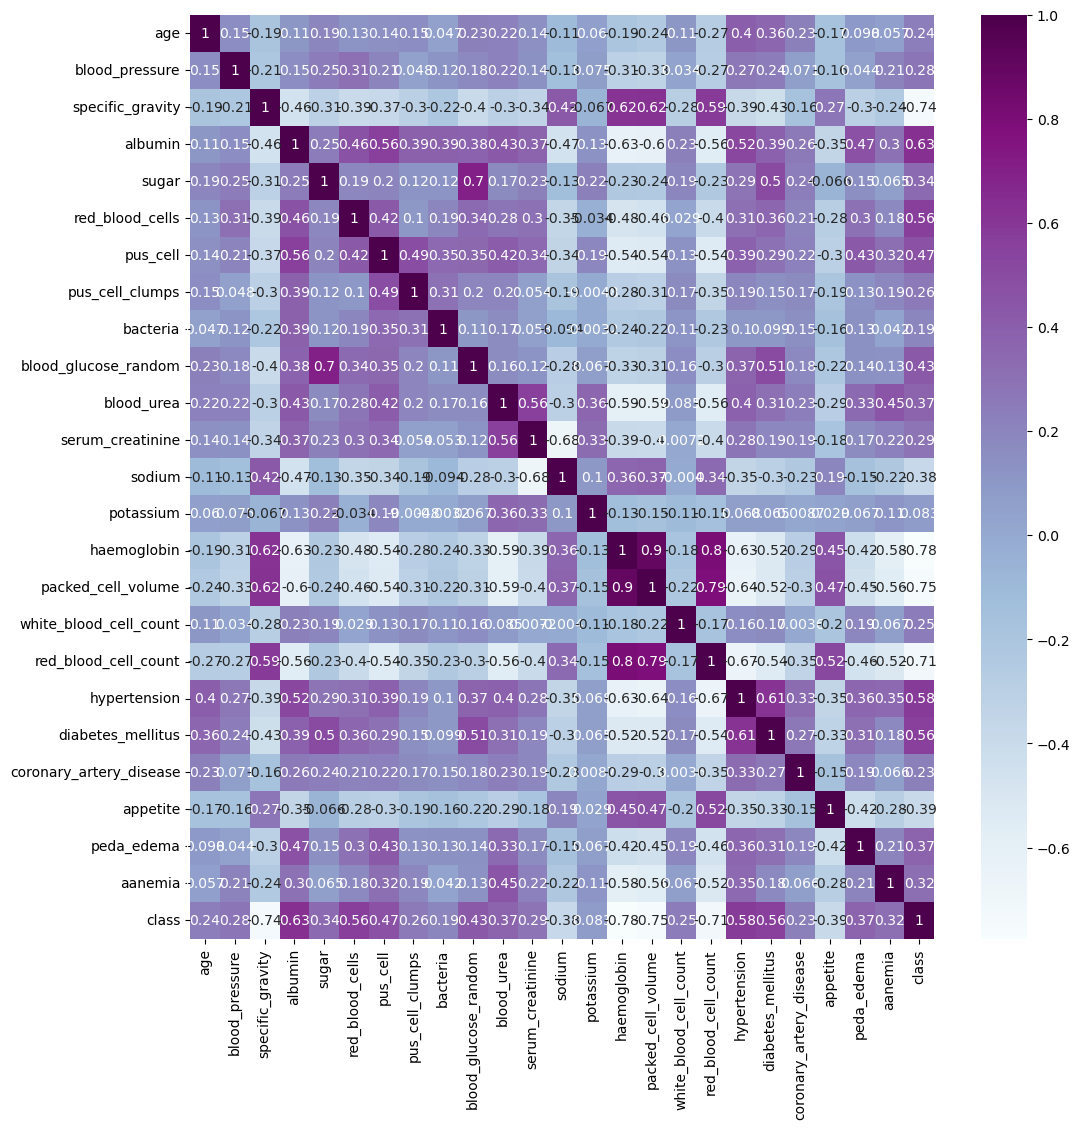

In [135]:
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(method='pearson'),cbar=True,cmap='BuPu',annot=True)

**Analyse distribution of red blood cell count chronic as well as non chronic**

In [137]:
result = df.groupby(['red_blood_cells', 'class'])['red_blood_cell_count'].agg(['count', 'mean', 'median', 'min', 'max'])
print(result)

                       count      mean  median  min  max
red_blood_cells class                                   
0.0             0       1662  5.375451    5.30  4.4  6.5
                1        510  3.820000    3.85  2.1  8.0
1.0             1        349  3.837249    3.70  2.5  5.6


**Relationship between haemoglobin and packed cell volume**

Text(0.5, 1.0, 'Relationship between haemoglobin and packed cell volume')

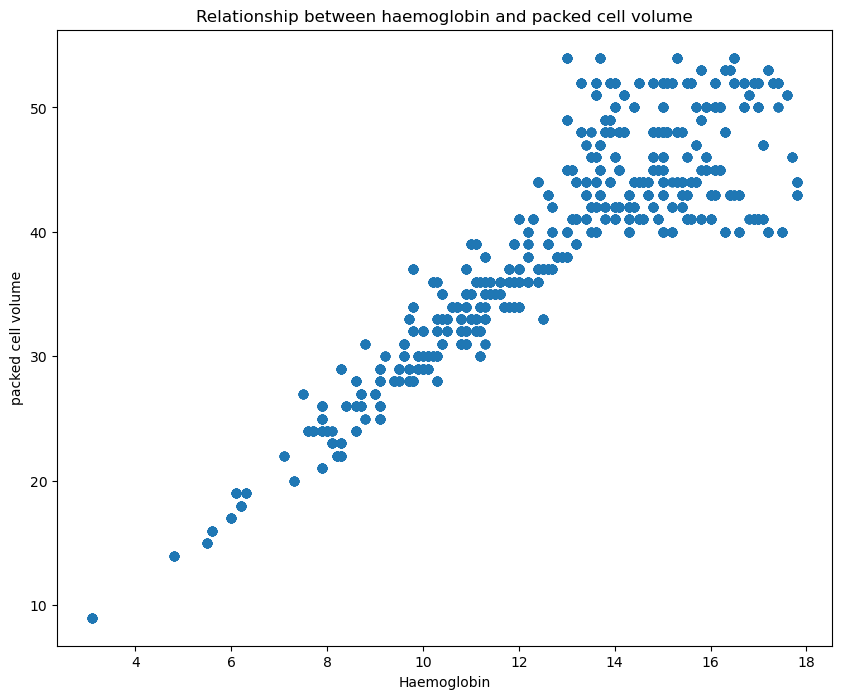

In [139]:
plt.figure(figsize=(10,8))
plt.scatter(x=df.haemoglobin,y=df['packed_cell_volume'])
plt.xlabel('Haemoglobin')
plt.ylabel('packed cell volume')
plt.title('Relationship between haemoglobin and packed cell volume')

**Analyse distribution of red blood cell count chronic as well as non chronic**

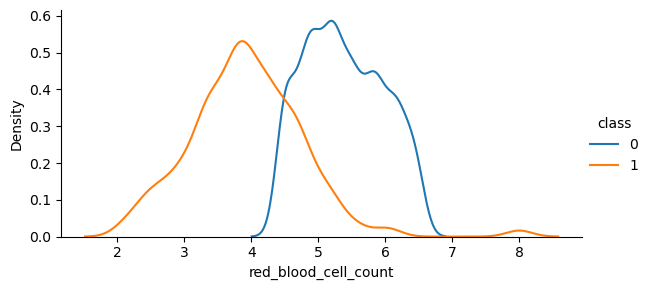

In [141]:
grid=sns.FacetGrid(df,hue='class',aspect=2)
grid.map(sns.kdeplot,'red_blood_cell_count')
grid.add_legend()

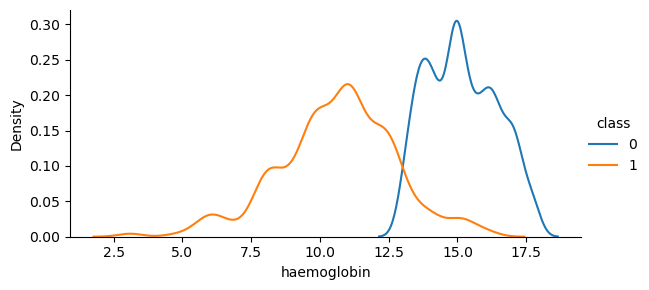

In [143]:
grid=sns.FacetGrid(df,hue='class',aspect=2)
grid.map(sns.kdeplot,'haemoglobin')
grid.add_legend()

Text(0.5, 1.0, 'Relationship between red blood cell count and packed cell volume')

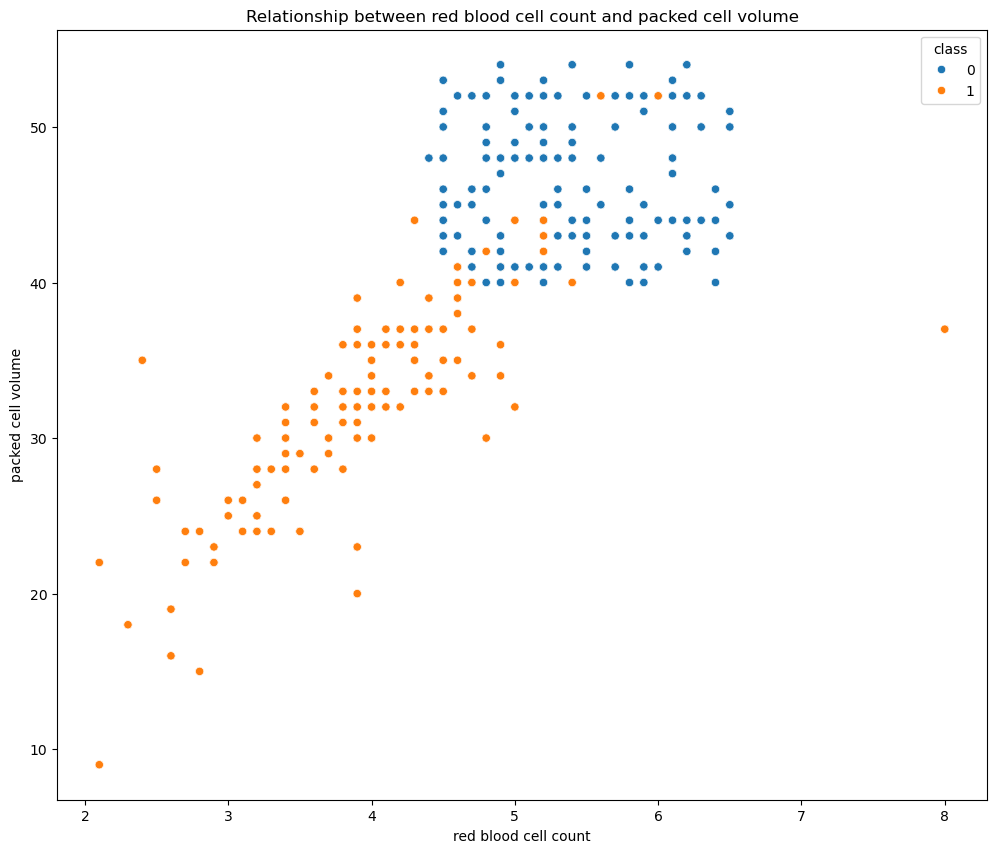

In [145]:
plt.figure(figsize=(12,10))
sns.scatterplot(x=df['red_blood_cell_count'],y=df['packed_cell_volume'],hue=df['class'])
plt.xlabel('red blood cell count')
plt.ylabel('packed cell volume')
plt.title('Relationship between red blood cell count and packed cell volume')

Text(0.5, 1.0, 'Relationship between haemoglobin and red blood cell count')

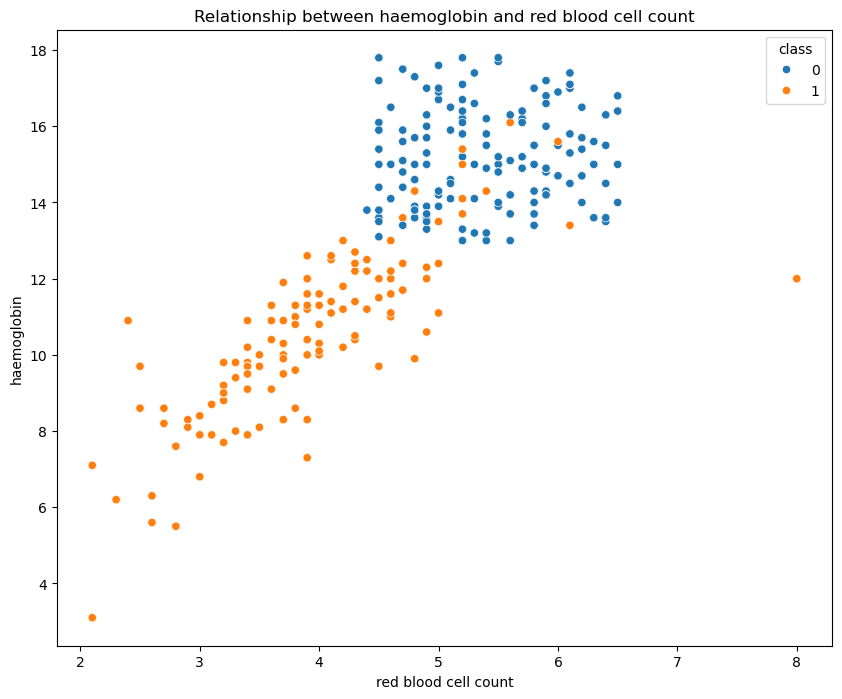

In [147]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=df['red_blood_cell_count'],y=df['haemoglobin'],hue=df['class'])
plt.xlabel('red blood cell count')
plt.ylabel('haemoglobin')
plt.title('Relationship between haemoglobin and red blood cell count')

**Handling Missing Values**

In [149]:
df.isnull().sum()

age                         123
blood_pressure              166
specific_gravity            577
albumin                     557
sugar                       599
red_blood_cells            1841
pus_cell                    814
pus_cell_clumps              44
bacteria                     44
blood_glucose_random        570
blood_urea                  242
serum_creatinine            221
sodium                     1087
potassium                  1099
haemoglobin                 667
packed_cell_volume          907
white_blood_cell_count     1320
red_blood_cell_count       1604
hypertension                 22
diabetes_mellitus            22
coronary_artery_disease      22
appetite                     12
peda_edema                   12
aanemia                      12
class                         0
dtype: int64

In [151]:
df.isnull().sum().sort_values(ascending=False)

red_blood_cells            1841
red_blood_cell_count       1604
white_blood_cell_count     1320
potassium                  1099
sodium                     1087
packed_cell_volume          907
pus_cell                    814
haemoglobin                 667
sugar                       599
specific_gravity            577
blood_glucose_random        570
albumin                     557
blood_urea                  242
serum_creatinine            221
blood_pressure              166
age                         123
bacteria                     44
pus_cell_clumps              44
hypertension                 22
diabetes_mellitus            22
coronary_artery_disease      22
appetite                     12
peda_edema                   12
aanemia                      12
class                         0
dtype: int64

<Axes: xlabel='class', ylabel='age'>

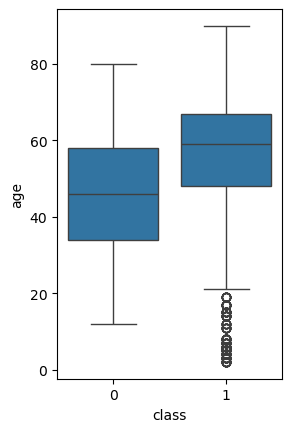

In [153]:
plt.subplot(1,2,1)
sns.boxplot(x=df['class'],y=df['age'])

In [155]:
list(enumerate(cat_col))

[(0, 'red_blood_cells'),
 (1, 'pus_cell'),
 (2, 'pus_cell_clumps'),
 (3, 'bacteria'),
 (4, 'hypertension'),
 (5, 'diabetes_mellitus'),
 (6, 'coronary_artery_disease'),
 (7, 'appetite'),
 (8, 'peda_edema'),
 (9, 'aanemia'),
 (10, 'class')]

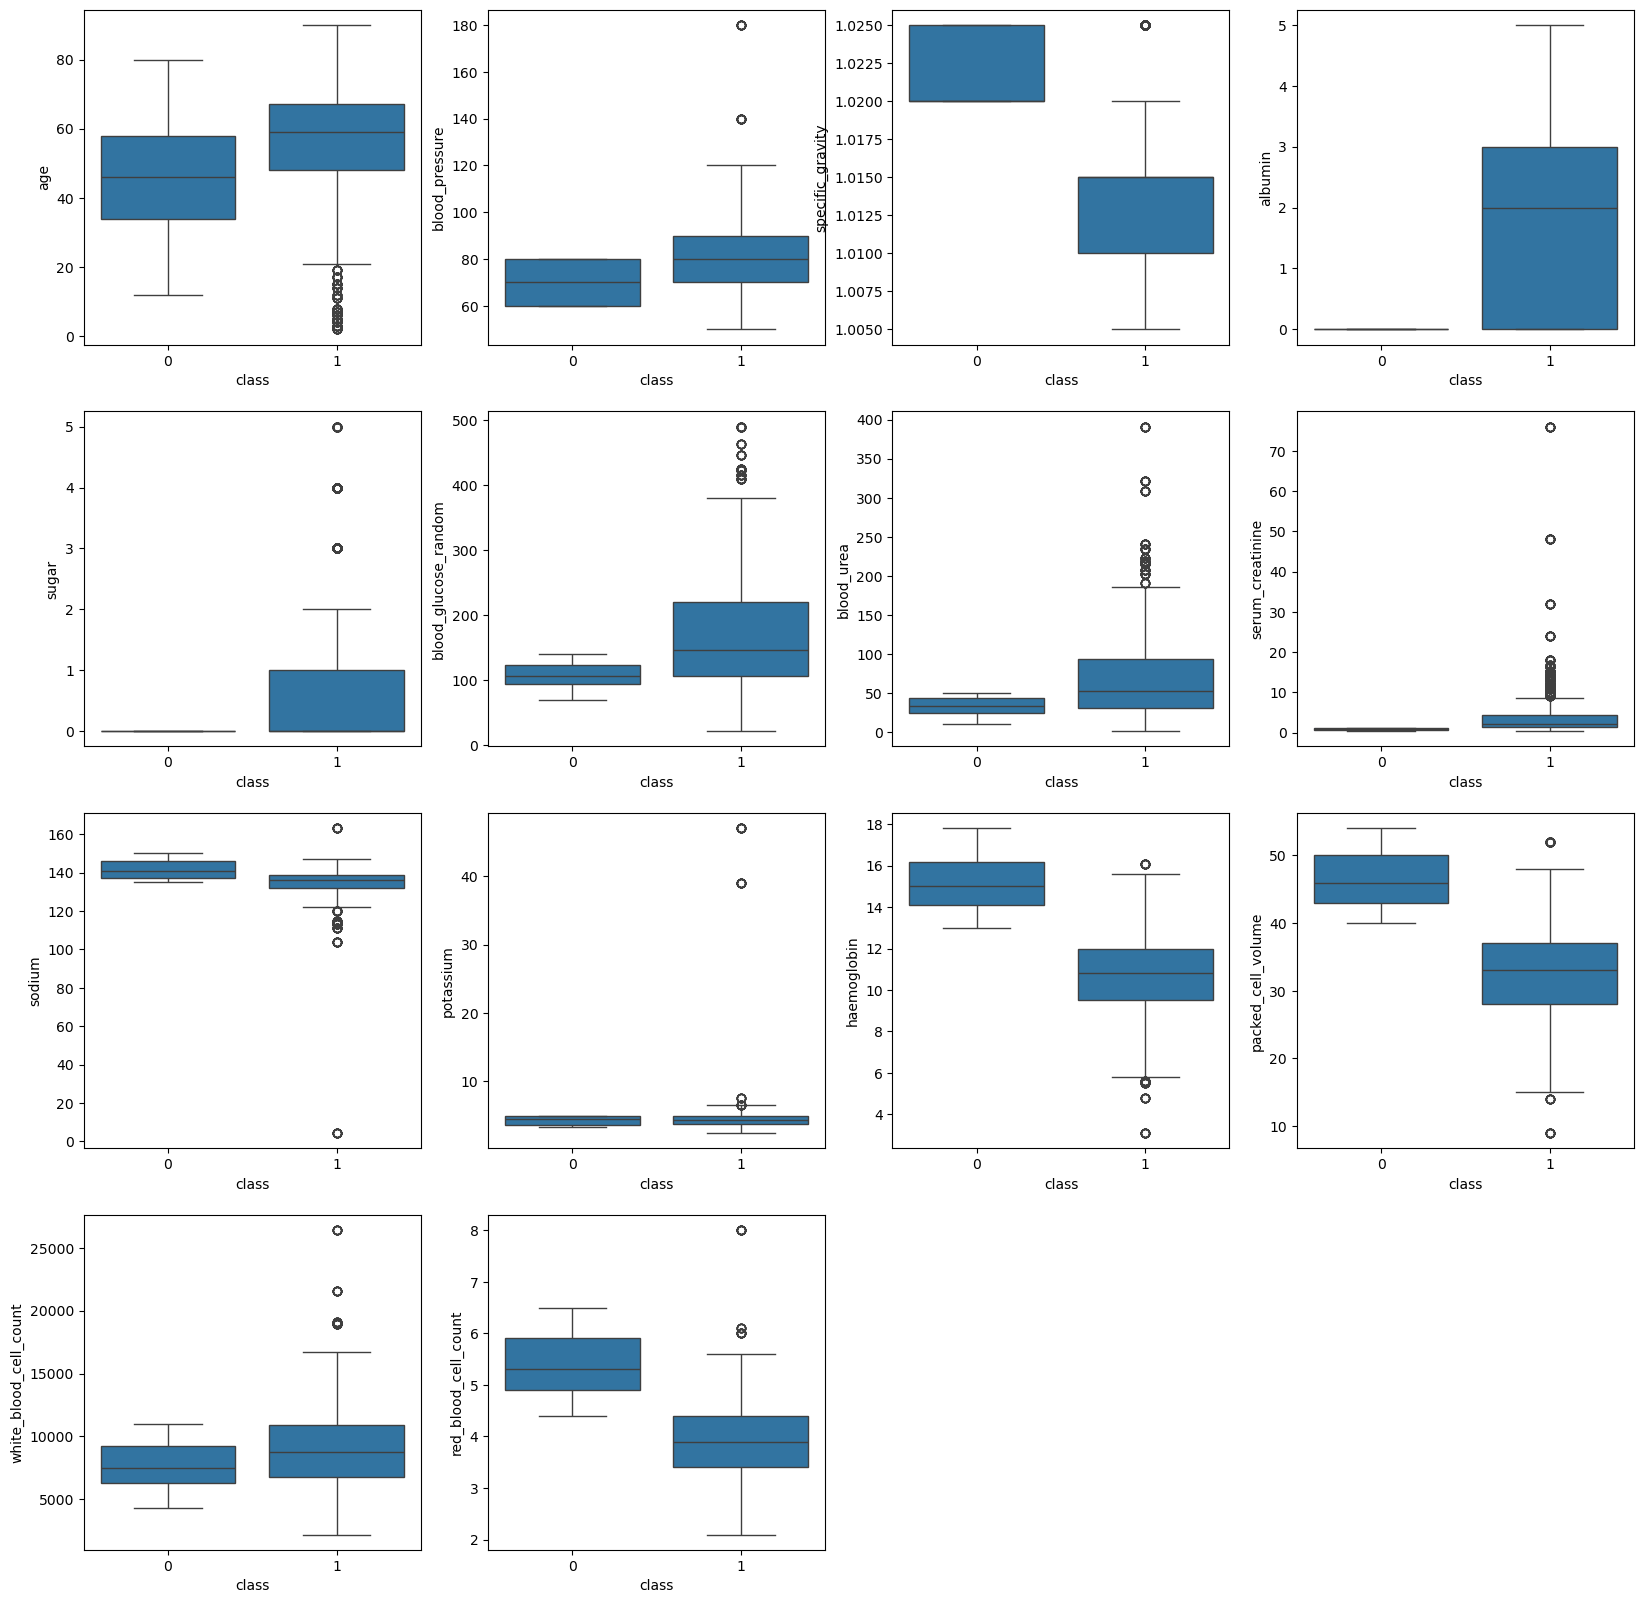

In [157]:
plt.figure(figsize=(20,20))
for i in enumerate(num_col):
    plt.subplot(4,4,i[0]+1)
    sns.boxplot(x=df['class'],y=i[1],data=df.reset_index())

In [159]:
import numpy as np

mean_values = np.mean(df.select_dtypes(include=[np.number]), axis=0)
print(mean_values)


age                          51.759073
blood_pressure               76.315681
specific_gravity              1.017421
albumin                       1.018006
sugar                         0.444672
red_blood_cells               0.201013
pus_cell                      0.231008
pus_cell_clumps               0.102704
bacteria                      0.057910
blood_glucose_random        148.620767
blood_urea                   57.462589
serum_creatinine              3.059761
sodium                      137.438283
potassium                     4.632274
haemoglobin                  12.512116
packed_cell_volume           38.860982
white_blood_cell_count     8403.206522
red_blood_cell_count          4.689782
hypertension                  0.363600
diabetes_mellitus             0.347730
coronary_artery_disease       0.080755
appetite                      0.795509
peda_edema                    0.189655
aanemia                       0.145148
class                         0.625800
dtype: float64


In [161]:
df.isnull().sum()

age                         123
blood_pressure              166
specific_gravity            577
albumin                     557
sugar                       599
red_blood_cells            1841
pus_cell                    814
pus_cell_clumps              44
bacteria                     44
blood_glucose_random        570
blood_urea                  242
serum_creatinine            221
sodium                     1087
potassium                  1099
haemoglobin                 667
packed_cell_volume          907
white_blood_cell_count     1320
red_blood_cell_count       1604
hypertension                 22
diabetes_mellitus            22
coronary_artery_disease      22
appetite                     12
peda_edema                   12
aanemia                      12
class                         0
dtype: int64

In [163]:
for i in num_col:
    df[i] = df[i].fillna(df[i].median())


In [165]:
df.isnull().sum()

age                           0
blood_pressure                0
specific_gravity              0
albumin                       0
sugar                         0
red_blood_cells            1841
pus_cell                    814
pus_cell_clumps              44
bacteria                     44
blood_glucose_random          0
blood_urea                    0
serum_creatinine              0
sodium                        0
potassium                     0
haemoglobin                   0
packed_cell_volume            0
white_blood_cell_count        0
red_blood_cell_count          0
hypertension                 22
diabetes_mellitus            22
coronary_artery_disease      22
appetite                     12
peda_edema                   12
aanemia                      12
class                         0
dtype: int64

In [167]:
df.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,3159.000000,4186.000000,4956.000000,4956.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,4978.000000,4978.000000,4978.000000,4988.000000,4988.000000,4988.000000,5000.000000
mean,51.838800,76.438000,1.017719,0.904600,0.391400,0.201013,0.231008,0.102704,0.057910,145.472000,...,39.067600,8296.760000,4.693060,0.363600,0.347730,0.080755,0.795509,0.189655,0.145148,0.625800
std,17.025028,13.353944,0.005415,1.313562,1.043467,0.400821,0.421528,0.303602,0.233596,74.236262,...,8.108204,2485.965709,0.845826,0.481084,0.476298,0.272486,0.403369,0.392067,0.352286,0.483964
min,2.000000,50.000000,1.005000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,...,9.000000,2200.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,43.000000,70.000000,1.015000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,102.000000,...,34.000000,7000.000000,4.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,121.000000,...,40.000000,8000.000000,4.700000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,64.000000,80.000000,1.020000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,153.000000,...,44.000000,9300.000000,5.100000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,490.000000,...,54.000000,26400.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Filling missing values in categorical columns using random values**

In [169]:
df['red_blood_cells'].isnull().sum()

1841

In [171]:
random_sample=df['red_blood_cells'].dropna().sample(1841)

In [173]:
random_sample

3054    1.0
3439    0.0
4982    1.0
4923    1.0
276     0.0
       ... 
981     0.0
871     0.0
4740    0.0
3078    0.0
483     0.0
Name: red_blood_cells, Length: 1841, dtype: float64

In [175]:
df[df['red_blood_cells'].isnull()].index

Index([   0,    1,    5,    6,   10,   12,   13,   15,   16,   17,
       ...
       4985, 4987, 4988, 4990, 4991, 4993, 4995, 4996, 4997, 4998],
      dtype='int64', length=1841)

In [177]:
random_sample.index

Index([3054, 3439, 4982, 4923,  276, 1368, 2189, 2202, 4413, 4126,
       ...
       3076,   74, 2801, 4481,  797,  981,  871, 4740, 3078,  483],
      dtype='int64', length=1841)

In [179]:
random_sample.index=df[df['red_blood_cells'].isnull()].index    #in this way index will be equal

In [181]:
random_sample.index

Index([   0,    1,    5,    6,   10,   12,   13,   15,   16,   17,
       ...
       4985, 4987, 4988, 4990, 4991, 4993, 4995, 4996, 4997, 4998],
      dtype='int64', length=1841)

In [183]:
df.loc[df['red_blood_cells'].isnull(),'red_blood_cells']=random_sample

In [185]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,1.0,0.0,0.0,0.0,121.0,...,44.0,7800.0,5.2,1.0,1.0,0.0,1.0,0.0,0.0,1
1,7.0,50.0,1.020,4.0,0.0,0.0,0.0,0.0,0.0,121.0,...,38.0,6000.0,4.7,0.0,0.0,0.0,1.0,0.0,0.0,1
2,62.0,80.0,1.010,2.0,3.0,0.0,0.0,0.0,0.0,423.0,...,31.0,7500.0,4.7,0.0,1.0,0.0,0.0,0.0,1.0,1
3,48.0,70.0,1.005,4.0,0.0,0.0,1.0,1.0,0.0,117.0,...,32.0,6700.0,3.9,1.0,0.0,0.0,0.0,1.0,1.0,1
4,51.0,80.0,1.010,2.0,0.0,0.0,0.0,0.0,0.0,106.0,...,35.0,7300.0,4.6,0.0,0.0,0.0,1.0,0.0,0.0,1


In [187]:
df['red_blood_cells'].isnull().sum()

0

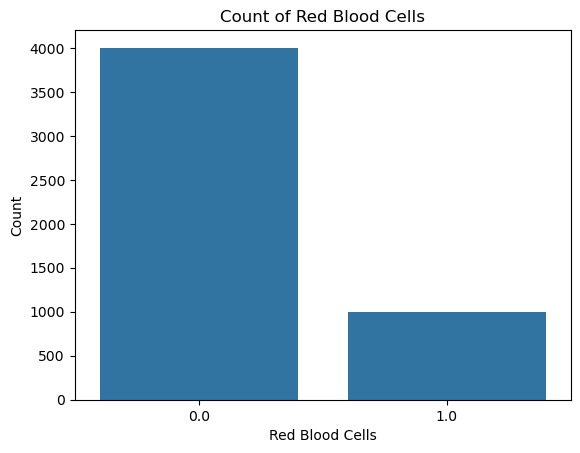

In [189]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['red_blood_cells'])
plt.xlabel('Red Blood Cells')
plt.ylabel('Count')
plt.title('Count of Red Blood Cells')
plt.show()
     # checking that ratio didnt change after filling missing values

In [191]:
#filling random values in all categorical columns
def Random_value_Imputation(feature):
    random_sample=df[feature].dropna().sample(df[feature].isnull().sum())
    random_sample.index=df[df[feature].isnull()].index
    df.loc[df[feature].isnull(),feature]=random_sample

In [193]:
Random_value_Imputation('pus_cell')  

In [195]:
df.isnull().sum()

age                         0
blood_pressure              0
specific_gravity            0
albumin                     0
sugar                       0
red_blood_cells             0
pus_cell                    0
pus_cell_clumps            44
bacteria                   44
blood_glucose_random        0
blood_urea                  0
serum_creatinine            0
sodium                      0
potassium                   0
haemoglobin                 0
packed_cell_volume          0
white_blood_cell_count      0
red_blood_cell_count        0
hypertension               22
diabetes_mellitus          22
coronary_artery_disease    22
appetite                   12
peda_edema                 12
aanemia                    12
class                       0
dtype: int64

In [197]:
def impute_mode(feature):
    mode=df[feature].mode()[0]
    df[feature]=df[feature].fillna(mode)

In [199]:
for col in cat_col:
    impute_mode(col)

In [201]:
df[cat_col].isnull().sum()

red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
peda_edema                 0
aanemia                    0
class                      0
dtype: int64

In [203]:
df.isnull().sum()

age                        0
blood_pressure             0
specific_gravity           0
albumin                    0
sugar                      0
red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
blood_glucose_random       0
blood_urea                 0
serum_creatinine           0
sodium                     0
potassium                  0
haemoglobin                0
packed_cell_volume         0
white_blood_cell_count     0
red_blood_cell_count       0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
peda_edema                 0
aanemia                    0
class                      0
dtype: int64

**Performing the Feature Encoding**

In [205]:
for col in cat_col:
    print('{} has {} categories'.format(col,df[col].nunique()))

red_blood_cells has 2 categories
pus_cell has 2 categories
pus_cell_clumps has 2 categories
bacteria has 2 categories
hypertension has 2 categories
diabetes_mellitus has 2 categories
coronary_artery_disease has 2 categories
appetite has 2 categories
peda_edema has 2 categories
aanemia has 2 categories
class has 2 categories


LabelEncoder can be used to normalize labels. It can also be used to transform non-numerical labels (as long as they are hashable and comparable) to numerical labels. Fit label encoder.
normal -- 0
abnormal --1

In [207]:
 from sklearn.preprocessing import LabelEncoder

In [209]:
le=LabelEncoder()

In [211]:
for col in cat_col:
    df[col]=le.fit_transform(df[col])

In [213]:
df.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,1,0,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,1,0,0,1
1,7.0,50.0,1.020,4.0,0.0,0,0,0,0,121.0,...,38.0,6000.0,4.7,0,0,0,1,0,0,1
2,62.0,80.0,1.010,2.0,3.0,0,0,0,0,423.0,...,31.0,7500.0,4.7,0,1,0,0,0,1,1
3,48.0,70.0,1.005,4.0,0.0,0,1,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,0,1,1,1
4,51.0,80.0,1.010,2.0,0.0,0,0,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,1,0,0,1


In [215]:
from sklearn.feature_selection import SelectKBest

In [217]:
from sklearn.feature_selection import chi2

In [219]:
ind_col=[col for col in df.columns if col!='class']
dep_col='class'

In [223]:
X=df[ind_col]
y=df[dep_col]

In [225]:
X.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia
0,48.0,80.0,1.020,1.0,0.0,1,0,0,0,121.0,...,15.4,44.0,7800.0,5.2,1,1,0,1,0,0
1,7.0,50.0,1.020,4.0,0.0,0,0,0,0,121.0,...,11.3,38.0,6000.0,4.7,0,0,0,1,0,0
2,62.0,80.0,1.010,2.0,3.0,0,0,0,0,423.0,...,9.6,31.0,7500.0,4.7,0,1,0,0,0,1
3,48.0,70.0,1.005,4.0,0.0,0,1,1,0,117.0,...,11.2,32.0,6700.0,3.9,1,0,0,0,1,1
4,51.0,80.0,1.010,2.0,0.0,0,0,0,0,106.0,...,11.6,35.0,7300.0,4.6,0,0,0,1,0,0


In [227]:
imp_features=SelectKBest(score_func=chi2,k=20)

In [229]:
imp_features=imp_features.fit(X,y)
imp_features

SelectKBest(k=20, score_func=<function chi2 at 0x0000015E746CC0E0>)

In [231]:
imp_features.scores_

array([1.57436101e+03, 9.34536045e+02, 6.39977824e-02, 2.70454874e+03,
       1.17019719e+03, 5.34552076e+02, 5.97506790e+02, 3.04358901e+02,
       1.71612975e+02, 2.82101045e+04, 2.84225815e+04, 4.38966220e+03,
       3.31447694e+02, 3.72102994e+01, 1.54467977e+03, 3.85977341e+03,
       1.35413505e+05, 2.73262151e+02, 1.08229786e+03, 1.03505944e+03,
       2.40377756e+02, 1.56309544e+02, 5.65665069e+02, 4.32919143e+02])

In [233]:
datascore=pd.DataFrame(imp_features.scores_,columns=['Score'])

In [235]:
datascore

,Score
0,1574.361014
1,934.536045
2,0.063998
3,2704.548738
4,1170.197188
5,534.552076
6,597.506790
7,304.358901
8,171.612975
9,28210.104494


In [237]:
X.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia'],
      dtype='object')

In [239]:
dfcols=pd.DataFrame(X.columns)

In [241]:
dfcols

,0
0,age
1,blood_pressure
2,specific_gravity
3,albumin
4,sugar
5,red_blood_cells
6,pus_cell
7,pus_cell_clumps
8,bacteria
9,blood_glucose_random


In [243]:
features_rank=pd.concat([dfcols,datascore],axis=1)
features_rank

,0,Score
0,age,1574.361014
1,blood_pressure,934.536045
2,specific_gravity,0.063998
3,albumin,2704.548738
4,sugar,1170.197188
5,red_blood_cells,534.552076
6,pus_cell,597.506790
7,pus_cell_clumps,304.358901
8,bacteria,171.612975
9,blood_glucose_random,28210.104494


In [245]:
features_rank.columns=['features','score']

In [247]:
features_rank

,features,score
0,age,1574.361014
1,blood_pressure,934.536045
2,specific_gravity,0.063998
3,albumin,2704.548738
4,sugar,1170.197188
5,red_blood_cells,534.552076
6,pus_cell,597.506790
7,pus_cell_clumps,304.358901
8,bacteria,171.612975
9,blood_glucose_random,28210.104494


In [249]:
features_rank.nlargest(10,'score')

,features,score
16,white_blood_cell_count,135413.505108
10,blood_urea,28422.581522
9,blood_glucose_random,28210.104494
11,serum_creatinine,4389.662205
15,packed_cell_volume,3859.773409
3,albumin,2704.548738
0,age,1574.361014
14,haemoglobin,1544.679769
4,sugar,1170.197188
18,hypertension,1082.297859


In [251]:
selected=features_rank.nlargest(10,'score')['features'].values

In [253]:
selected

array(['white_blood_cell_count', 'blood_urea', 'blood_glucose_random',
       'serum_creatinine', 'packed_cell_volume', 'albumin', 'age',
       'haemoglobin', 'sugar', 'hypertension'], dtype=object)

In [255]:
X_new=df[selected]

In [257]:
X_new.head()

,white_blood_cell_count,blood_urea,blood_glucose_random,serum_creatinine,packed_cell_volume,albumin,age,haemoglobin,sugar,hypertension
0,7800.0,36.0,121.0,1.2,44.0,1.0,48.0,15.4,0.0,1
1,6000.0,18.0,121.0,0.8,38.0,4.0,7.0,11.3,0.0,0
2,7500.0,53.0,423.0,1.8,31.0,2.0,62.0,9.6,3.0,0
3,6700.0,56.0,117.0,3.8,32.0,4.0,48.0,11.2,0.0,1
4,7300.0,26.0,106.0,1.4,35.0,2.0,51.0,11.6,0.0,0


In [259]:
len(X_new)

5000

In [261]:
X_new.shape

(5000, 10)

In [263]:
from sklearn.model_selection import train_test_split

In [265]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size = 0.3, random_state = 42)

In [267]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [269]:
print("Train Set: ", X_train.shape, y_train.shape)
print("Test Set: ", X_test.shape, y_test.shape)

Train Set:  (3500, 10) (3500,)
Test Set:  (1500, 10) (1500,)


**Linear Discriminant Analysis**

LDA Model Accuracy: 65.00%
Confusion Matrix:
 [[ 98 260]
 [ 90 552]]
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.27      0.36       358
           1       0.68      0.86      0.76       642

    accuracy                           0.65      1000
   macro avg       0.60      0.57      0.56      1000
weighted avg       0.62      0.65      0.62      1000



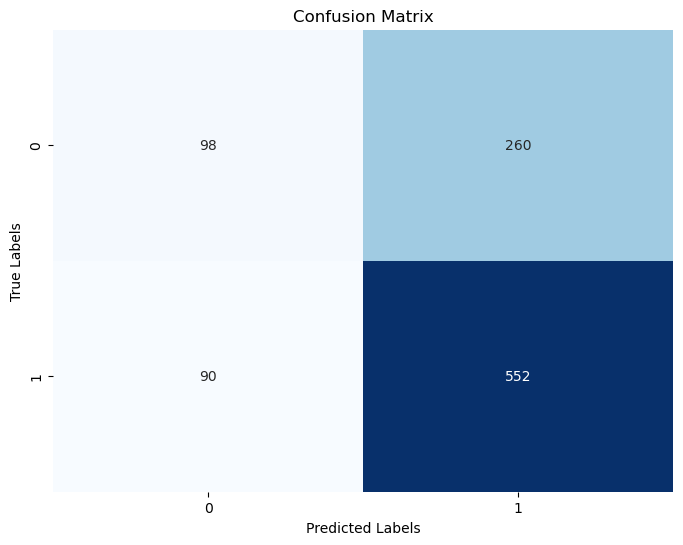

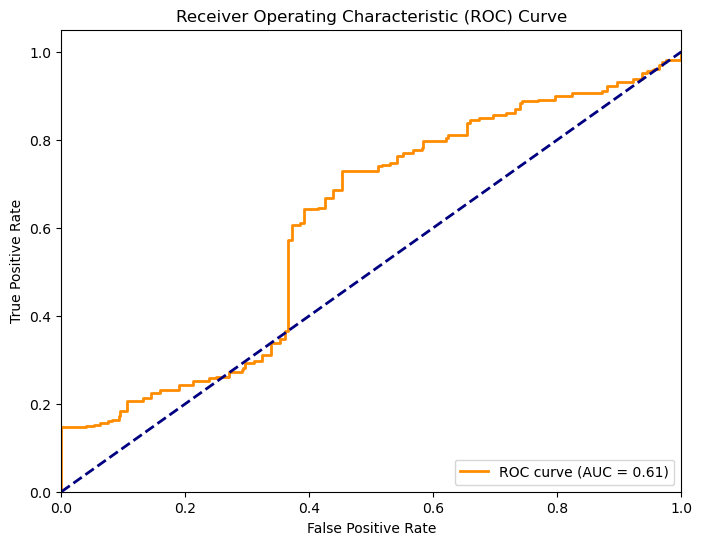

In [271]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

# Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Initialize the Linear Discriminant Analysis model with a fixed solver (no parameter tuning)
lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.5)

# Train the LDA model directly on unscaled data (not scaling features)
lda.fit(X_train, y_train)

# Make predictions on the test set
y_pred = lda.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"LDA Model Accuracy: {accuracy * 100:.2f}%")

# Generate confusion matrix and classification report
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# ROC Curve and AUC score
y_pred_prob = lda.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)  # Calculate False Positive Rate and True Positive Rate
roc_auc = auc(fpr, tpr)  # Calculate AUC score

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line for random chance
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


**Gradient Boosting**

Gradient Boosting Model Accuracy: 97.30%
Confusion Matrix:
 [[350   8]
 [ 19 623]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96       358
           1       0.99      0.97      0.98       642

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



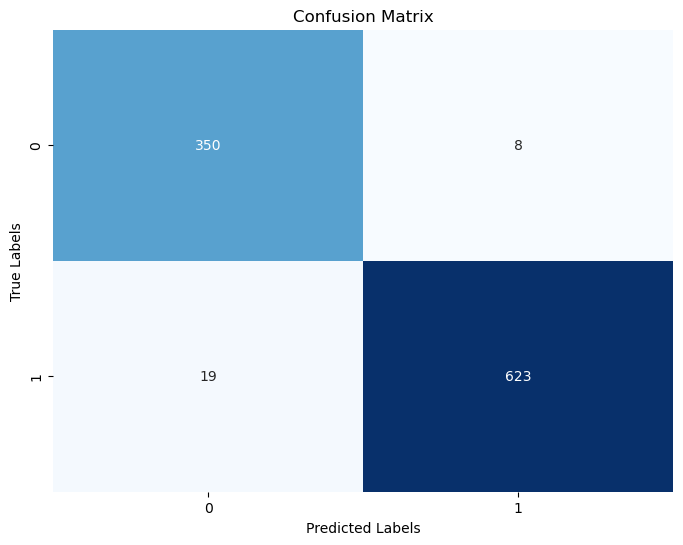

Cross-Validation Accuracy Scores: [0.9725 0.98   0.9675 0.98   0.9775]
Mean Cross-Validation Accuracy: 97.55%


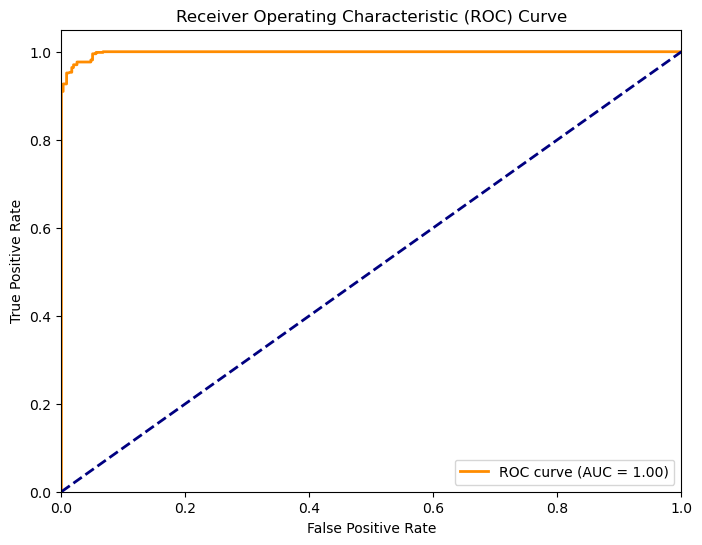

In [273]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

np.random.seed(42)
X_train_noisy = X_train + np.random.normal(0, 0.1, X_train.shape)
X_test_noisy = X_test + np.random.normal(0, 0.1, X_test.shape)

# Initialize the Gradient Boosting Classifier model with more suboptimal hyperparameters
gbc = GradientBoostingClassifier(
    n_estimators=30,        # Further reduce the number of trees
    learning_rate=0.3,      # Increase learning rate for more aggressive updates
    max_depth=1,            # Limit the depth of each tree to 1 (stumps)
    subsample=0.7,          # Use 70% of the data for each tree (increase randomness)
    random_state=42
)

# Train the model on the noisy training data
gbc.fit(X_train_noisy, y_train)

# Make predictions on the test set
y_pred = gbc.predict(X_test_noisy)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Gradient Boosting Model Accuracy: {accuracy * 100:.2f}%")

# Generate confusion matrix and classification report
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Perform 5-fold cross-validation
cv_scores = cross_val_score(gbc, X_train_noisy, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean Cross-Validation Accuracy: {:.2f}%".format(cv_scores.mean() * 100))

# ROC Curve and AUC score
y_pred_prob = gbc.predict_proba(X_test_noisy)[:, 1]  # Get probabilities for the positive class

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)  # Calculate False Positive Rate and True Positive Rate
roc_auc = auc(fpr, tpr)  # Calculate AUC score

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line for random chance
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()



**Ada Boost**

Cross-Validation Accuracy Scores: [0.9475  0.96125 0.94625 0.95625 0.96125]
Mean Cross-Validation Accuracy: 95.45%
AdaBoost Model Accuracy: 94.80%
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       358
           1       0.98      0.93      0.96       642

    accuracy                           0.95      1000
   macro avg       0.94      0.95      0.94      1000
weighted avg       0.95      0.95      0.95      1000



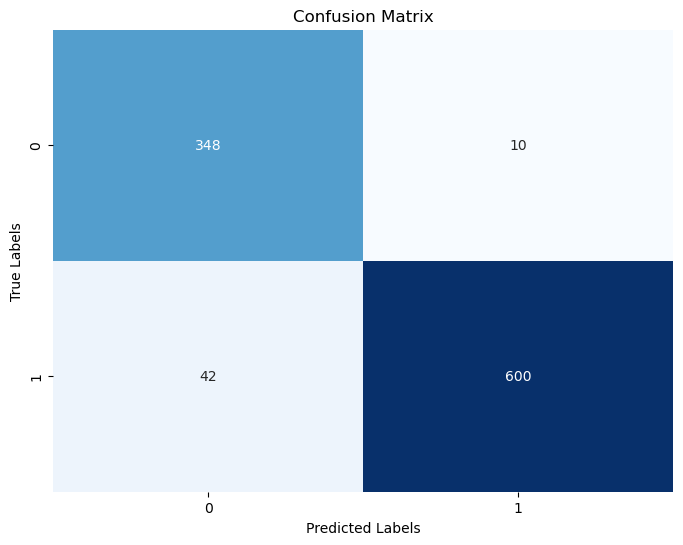

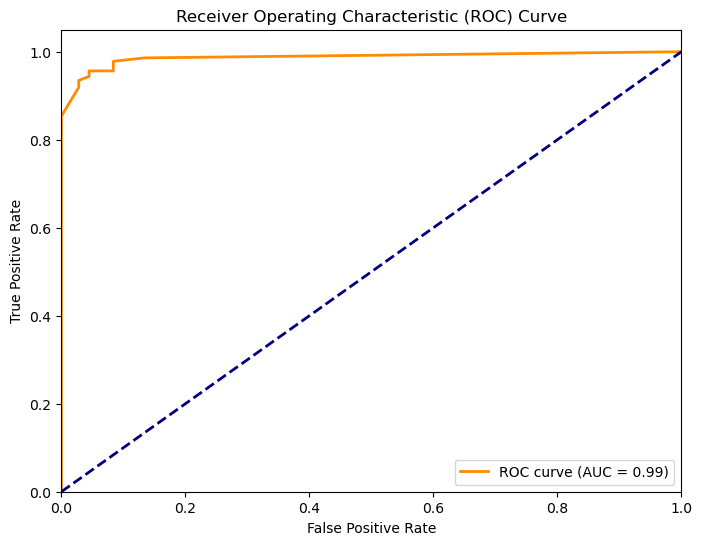

In [275]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier


X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1), 
    n_estimators=10,  
    learning_rate=0.3,  
    algorithm='SAMME', 
    random_state=42
)

# Perform 5-fold cross-validation on the training set
cv_scores = cross_val_score(ada_model, X_train, y_train, cv=5, scoring='accuracy')

# Print cross-validation scores and mean accuracy
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean Cross-Validation Accuracy: {:.2f}%".format(cv_scores.mean() * 100))

# Train the AdaBoost model
ada_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = ada_model.predict(X_test)

# Evaluate the model's performance
accuracy = np.sum(y_pred == y_test) / len(y_test)
print(f"AdaBoost Model Accuracy: {accuracy * 100:.2f}%")

# Generate confusion matrix and classification report
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, output_dict=True)

print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# ROC Curve and AUC score
y_pred_prob = ada_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)  # Calculate False Positive Rate and True Positive Rate
roc_auc = auc(fpr, tpr)  # Calculate AUC score

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line for random chance
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


**CNN**

C:\Users\sneha\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5942 - loss: 0.6370 - val_accuracy: 0.8600 - val_loss: 0.4095
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8451 - loss: 0.3729 - val_accuracy: 0.9475 - val_loss: 0.2026
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9335 - loss: 0.2010 - val_accuracy: 0.9575 - val_loss: 0.1289
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9484 - loss: 0.1481 - val_accuracy: 0.9650 - val_loss: 0.1026
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9697 - loss: 0.1088 - val_accuracy: 0.9787 - val_loss: 0.0796
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9666 - loss: 0.1067 - val_accuracy: 0.9812 - val_loss: 0.0716
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9673 - loss: 0.0879 - val_accuracy: 0.9800 - val_loss: 0.0642
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9727 - loss: 0.0807 - val_accuracy: 0.

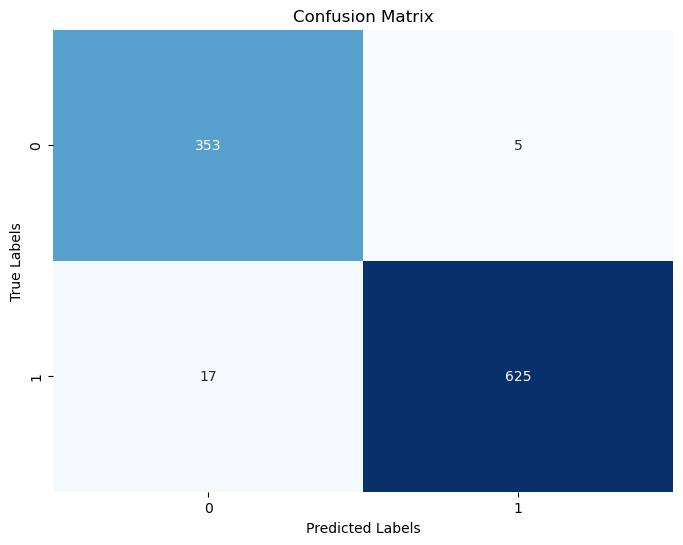

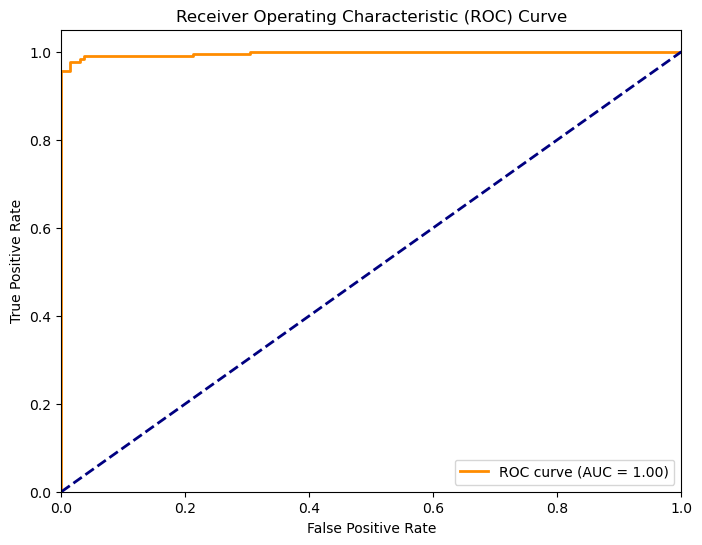

In [279]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to NumPy arrays and reshape for CNN
X_train_cnn = X_train_scaled.reshape(-1, 10, 1, 1)  # Adjust dimensions based on your data
X_test_cnn = X_test_scaled.reshape(-1, 10, 1, 1)    # Adjust dimensions based on your data

# Convert to float32
X_train_cnn = X_train_cnn.astype('float32')
X_test_cnn = X_test_cnn.astype('float32')

# Initialize the CNN model
cnn_model = Sequential()

# Add convolutional layers with reduced units
cnn_model.add(Conv2D(16, kernel_size=(2, 1), activation='relu', input_shape=(10, 1, 1)))  
cnn_model.add(MaxPooling2D(pool_size=(2, 1)))
cnn_model.add(Conv2D(32, kernel_size=(2, 1), activation='relu'))  # Reduced units
cnn_model.add(MaxPooling2D(pool_size=(2, 1)))

# Flatten the output
cnn_model.add(Flatten())

# Add fully connected layers with increased dropout
cnn_model.add(Dense(64, activation='relu'))  # Reduced units
cnn_model.add(Dropout(0.7))  # Increased dropout
cnn_model.add(Dense(1, activation='sigmoid'))  # Assuming binary classification

# Compile the model
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model with fewer epochs
history = cnn_model.fit(X_train_cnn, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model on the test set
loss, accuracy = cnn_model.evaluate(X_test_cnn, y_test, verbose=1)
print(f"CNN Model Accuracy: {accuracy * 100:.2f}%")

# Make predictions on the test set
y_pred_prob =cnn_model.predict(X_test_cnn).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# Generate confusion matrix and classification report
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# ROC Curve and AUC score
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)  # Calculate False Positive Rate and True Positive Rate
roc_auc = auc(fpr, tpr)  # Calculate AUC score

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line for random chance
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()



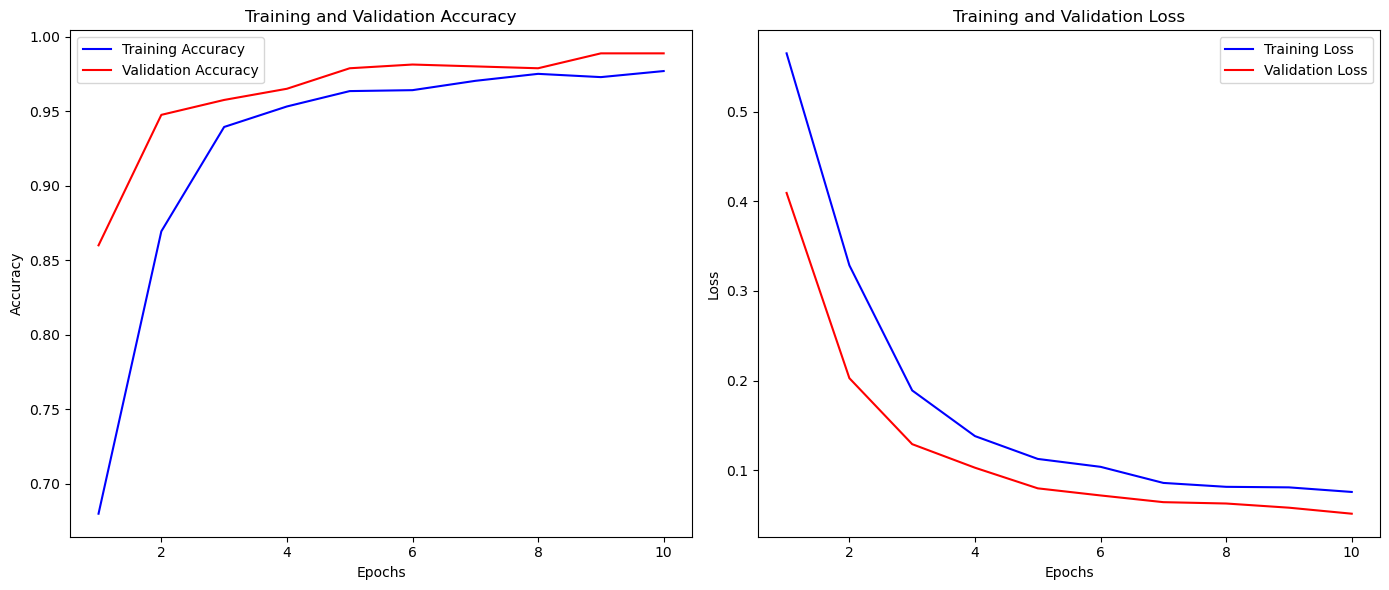

In [281]:
# Plot the training and validation accuracy and loss from the history object

# Get training and validation accuracy
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Get training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Create figure and axis
epochs = range(1, len(train_accuracy) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracy, 'b-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


**ANN**

Epoch 1/10


C:\Users\sneha\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5740 - loss: 0.6558 - val_accuracy: 0.9538 - val_loss: 0.3171
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9576 - loss: 0.2508 - val_accuracy: 0.9675 - val_loss: 0.1297
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9711 - loss: 0.1138 - val_accuracy: 0.9737 - val_loss: 0.0832
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9690 - loss: 0.0814 - val_accuracy: 0.9800 - val_loss: 0.0656
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9724 - loss: 0.0653 - val_accuracy: 0.9725 - val_loss: 0.0584
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9777 - loss: 0.0546 - val_accuracy: 0.9825 - val_loss: 0.0515
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9799 - loss: 0.0519 - val_accuracy: 0.9825 - val_loss: 0.0471
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9869 - loss: 0.0437 - val_accuracy: 0.9875 - val_

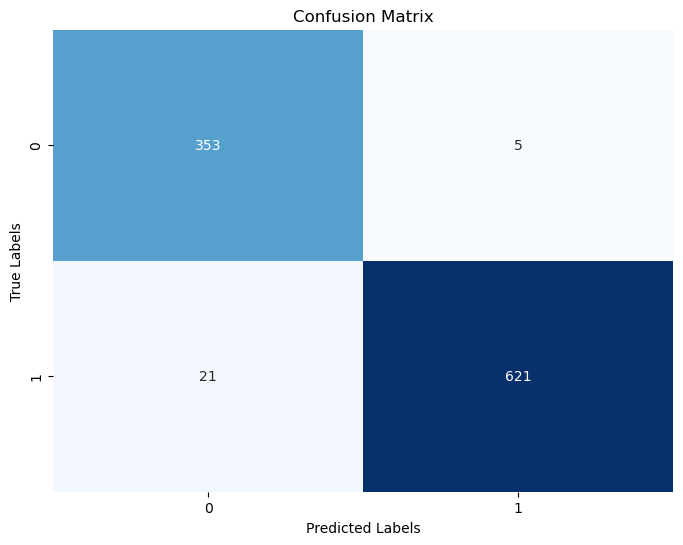

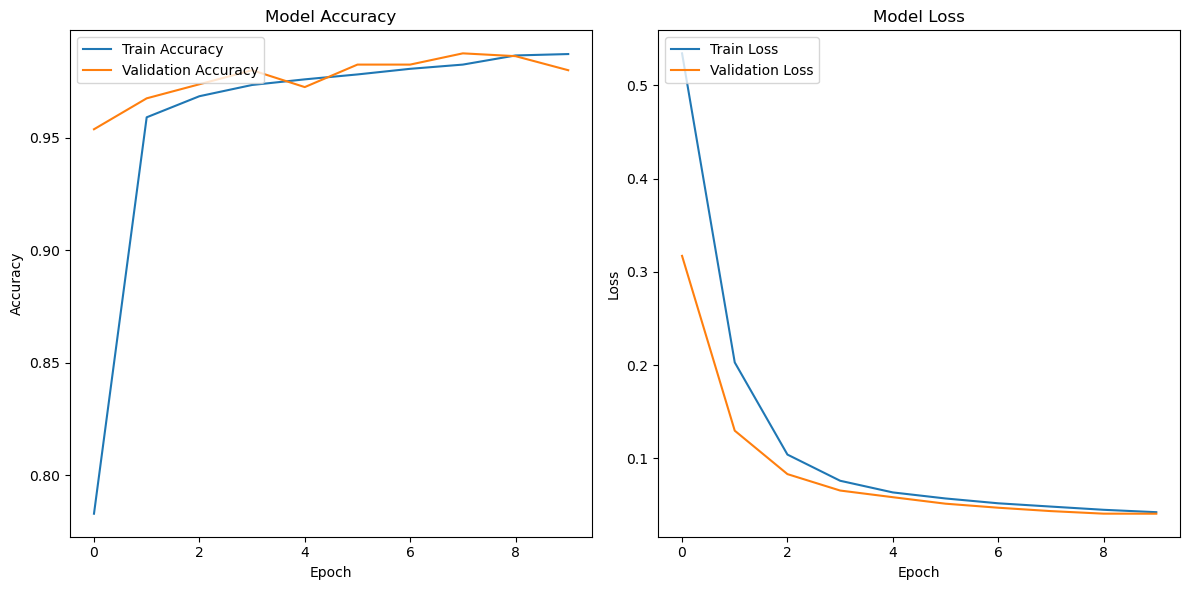

In [283]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Assuming X and y are already defined and preprocessed
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize the ANN model
ann_model = Sequential()

# Add input layer and first hidden layer
ann_model.add(Dense(units=16, activation='relu', input_shape=(X_train.shape[1],)))

# Add second hidden layer
ann_model.add(Dense(units=16, activation='relu'))

# Add output layer
ann_model.add(Dense(units=1, activation='sigmoid'))  # Sigmoid activation for binary classification

# Compile the model
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = ann_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model on test data
y_pred_prob = ann_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary class predictions

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"ANN Model Accuracy: {accuracy * 100:.2f}%")

# Generate confusion matrix and classification report
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
AUC Score: 1.00


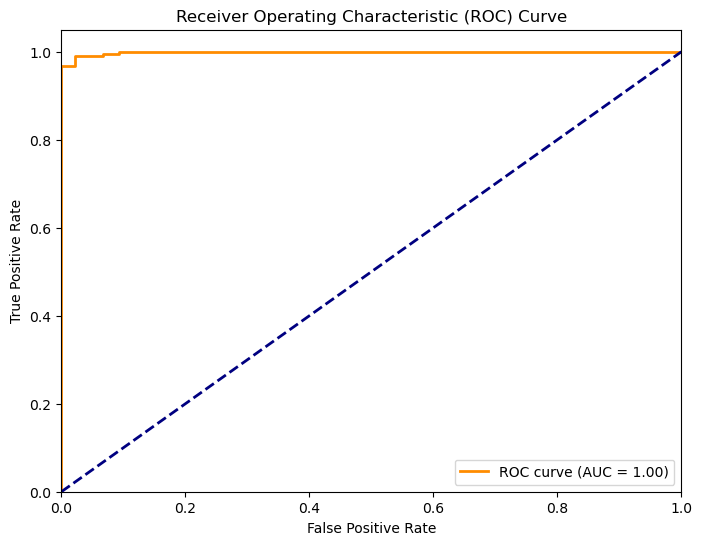

In [285]:
from sklearn.metrics import roc_curve, auc

# Get the predicted probabilities for the positive class
y_pred_prob = ann_model.predict(X_test).flatten()  # Flatten to ensure it's a 1D array

# Compute False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute the AUC (Area Under the Curve) score
roc_auc = auc(fpr, tpr)
print(f"AUC Score: {roc_auc:.2f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line for random chance
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


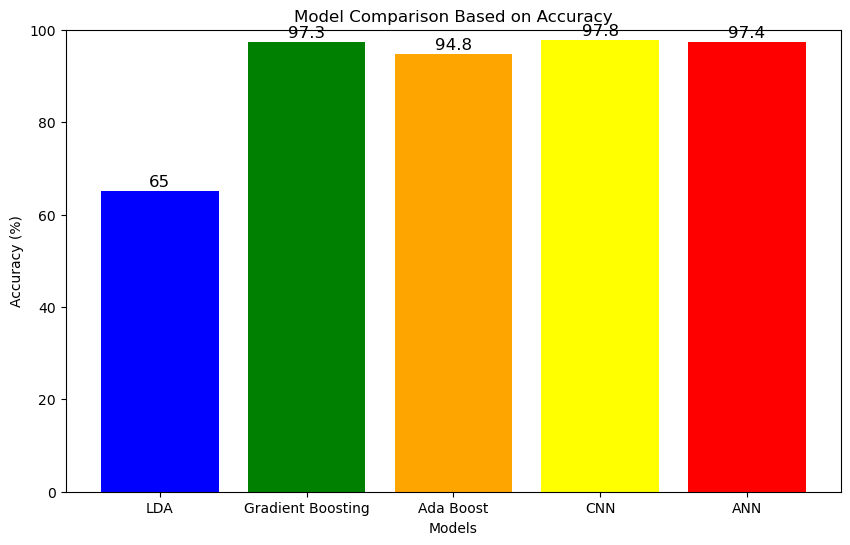

The best model is: CNN with an accuracy of 97.8%


In [297]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np

# Define model names and their corresponding accuracies
models = ['LDA', 'Gradient Boosting','Ada Boost', 'CNN', 'ANN', ]
accuracies = [65, 97.30,94.80, 97.80, 97.40]

# Plot the model accuracies
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'green', 'orange', 'yellow', 'red' ])
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison Based on Accuracy')
plt.ylim(0, 100)
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, str(v), ha='center', fontsize=12)
plt.show()

# Find the best model based on accuracy
best_model_index = np.argmax(accuracies)
best_model_name = models[best_model_index]
print(f"The best model is: {best_model_name} with an accuracy of {accuracies[best_model_index]}%")

In [299]:
from tensorflow.keras.models import save_model

# Path where you want to save the CNN model
model_path = 'C:/Users/sneha/major project/model_save/kidney_cnn_model.h5'

# Save the trained CNN model
cnn_model.save(model_path)

print(f"CNN model saved successfully at {model_path}.")

CNN model saved successfully at C:/Users/sneha/major project/model_save/kidney_cnn_model.h5.


In [309]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 9, 1, 16)       │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 1, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 1, 32)       │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,845 (38.46 KB)

 Trainable params: 3,281 (12.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,564 (25.64 KB)

In [311]:
import numpy as np
from tensorflow.keras.models import load_model

# Path where the model is saved
model_path = 'C:/Users/sneha/major project/model_save/kidney_cnn_model.h5'

# Load the saved CNN model
cnn_model = load_model(model_path)

# Define the input data (single sample as numpy array based on your features)
input_data = np.array([
    [7800.0, 36.0, 121.0, 1.2, 44.0, 1.0, 48.0, 15.4, 0.0, 1]  # Example input data
])

# Reshape input data to match the expected input shape: (batch_size, 10, 1, 1)
input_data = input_data.reshape(input_data.shape[0], input_data.shape[1], 1, 1)

# Perform the prediction
predictions = cnn_model.predict(input_data)

# Output the predictions (if the output is a probability)
print("Predictions: ", predictions)

# Convert probabilities to binary classes (assuming a threshold of 0.5 for binary classification)
predicted_classes = (predictions > 0.5).astype(int)
print("Predicted Classes: ", predicted_classes)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
Predictions:  [[1.]]
Predicted Classes:  [[1]]


In [313]:
import numpy as np
from tensorflow.keras.models import load_model

# Path where the model is saved
model_path = 'C:/Users/sneha/major project/model_save/kidney_cnn_model.h5'

# Load the saved CNN model
cnn_model = load_model(model_path)

# Define the input data (single sample as numpy array based on your features)
input_data = np.array([
    [11000.0, 48.0, 127.0, 0.5, 52.0, 0.0, 73.0, 15.1, 0.0, 0]  # Example input data
])

# Reshape input data to match the expected input shape: (batch_size, 10, 1, 1)
input_data = input_data.reshape(input_data.shape[0], input_data.shape[1], 1, 1)

# Perform the prediction
predictions = cnn_model.predict(input_data)

# Output the predictions (if the output is a probability)
print("Predictions: ", predictions)

# Convert probabilities to binary classes (assuming a threshold of 0.5 for binary classification)
predicted_classes = (predictions > 0.5).astype(int)
print("Predicted Classes: ", predicted_classes)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Predictions:  [[1.]]
Predicted Classes:  [[1]]


In [315]:
import pickle
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

# Save the trained Gradient Boosting model
model_path = 'C:/Users/sneha/major project/model_save/kidney_gbc_model.pkl'
with open(model_path, 'wb') as file:
    pickle.dump(gbc, file)

# Save the scaler used for scaling the data
scaler_path = 'C:/Users/sneha/major project/model_save/kidney_scaler.pkl'
with open(scaler_path, 'wb') as file:
    pickle.dump(scaler, file)

In [317]:
import pickle
import numpy as np

# Define the path where the model and scaler are saved
model_path = 'C:/Users/sneha/major project/model_save/kidney_gbc_model.pkl'
scaler_path = 'C:/Users/sneha/major project/model_save/kidney_scaler.pkl'

# Load the trained model
with open(model_path, 'rb') as file:
    loaded_model = pickle.load(file)

# Load the scaler
with open(scaler_path, 'rb') as file:
    scaler = pickle.load(file)

# Define the new data using the provided parameters (ensure they are in the same order as the training data)
new_data = np.array([[11000.0, 48.0, 127.0, 0.5, 52.0, 0.0, 73.0, 15.1, 0.0, 0]])

# Scale the new data using the loaded scaler
new_data_scaled = scaler.transform(new_data)

# Debug output to check scaling (optional)
print("Scaled new data:", new_data_scaled)

# Make prediction
prediction = loaded_model.predict(new_data_scaled)

# Output the prediction result
if prediction[0] == 1:
    print("The person is predicted to have kidney disease.")
else:
    print("The person is predicted not to have kidney disease.")



Scaled new data: [[ 1.07052504 -0.17239617 -0.24618432 -0.41442957  1.58739209 -0.68562252
   1.23102459  0.9612641  -0.37206026 -0.7463418 ]]
The person is predicted to have kidney disease.


C:\Users\sneha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\sneha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [319]:
import pickle
import numpy as np

# Define the path where the model and scaler are saved
model_path = 'C:/Users/sneha/major project/model_save/kidney_xgb_model.pkl'
scaler_path = 'C:/Users/sneha/major project/model_save/kidney_scaler.pkl'

# Load the trained model
with open(model_path, 'rb') as file:
    loaded_model = pickle.load(file)

# Load the scaler
with open(scaler_path, 'rb') as file:
    scaler = pickle.load(file)

# Define the new data using the provided parameters (ensure they are in the same order as the training data)
new_data = np.array([[7800.0, 36.0, 121.0, 1.2, 44.0, 1.0, 48.0, 15.4, 0.0, 1]])

# Scale the new data using the loaded scaler
new_data_scaled = scaler.transform(new_data)

# Debug output to check scaling (optional)
print("Scaled new data:", new_data_scaled)

# Make prediction
prediction = loaded_model.predict(new_data_scaled)

# Output the prediction result
if prediction[0] == 1:
    print("The person is predicted to have kidney disease.")
else:
    print("The person is predicted not to have kidney disease.")

Scaled new data: [[-0.20679633 -0.41399895 -0.32687844 -0.29802728  0.60105137  0.07979475
  -0.23587792  1.07345427 -0.37206026  1.33986868]]
The person is predicted to have kidney disease.


C:\Users\sneha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
